In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import requests
import os

print("AeroPure W2 environment is ready!")
print("Python environment is working.")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

AeroPure W2 environment is ready!
Python environment is working.
Pandas: 3.0.1
NumPy: 2.4.1
Scikit-learn: 1.9.0


In [2]:
print(os.listdir("../data/raw/air_quality"))

['city_day.csv']


In [3]:
df = pd.read_csv("../data/raw/air_quality/city_day.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Dataset loaded successfully!
Rows: 29531
Columns: 16


In [4]:
df.head()
df.shape
df.columns.tolist()
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 29531
Number of columns: 16


In [6]:
print("Columns in the dataset:")
for i, col in enumerate(df.columns, start=1):
    print(i, "→", col)

Columns in the dataset:
1 → City
2 → Date
3 → PM2.5
4 → PM10
5 → NO
6 → NO2
7 → NOx
8 → NH3
9 → CO
10 → SO2
11 → O3
12 → Benzene
13 → Toluene
14 → Xylene
15 → AQI
16 → AQI_Bucket


In [7]:
df.head()


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [8]:
df.tail()


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory
29530,Visakhapatnam,2020-07-01,15.00,66.00,0.40,26.85,14.05,5.20,0.59,2.10,17.05,NaN,NaN,NaN,50.0,Good


In [9]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Earliest date:", df["Date"].min())
print("Latest date:", df["Date"].max())

Earliest date: 2015-01-01 00:00:00
Latest date: 2020-07-01 00:00:00


In [10]:
print("Invalid/missing dates:", df["Date"].isna().sum())

Invalid/missing dates: 0


In [11]:
print("Number of cities:", df["City"].nunique())


Number of cities: 26


In [12]:
print("Cities:")
print(sorted(df["City"].unique()))

Cities:
['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']


In [13]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [14]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,29531,2018-05-14 05:40:15.807118,2015-01-01 00:00:00,2017-04-16 00:00:00,2018-08-05 00:00:00,2019-09-03 00:00:00,2020-07-01 00:00:00,NaN
PM2.5,24933.0,67.450578,0.04,28.82,48.57,80.59,949.99,64.661449
PM10,18391.0,118.127103,0.01,56.255,95.68,149.745,1000.0,90.60511
NO,25949.0,17.57473,0.02,5.63,9.89,19.95,390.68,22.785846
NO2,25946.0,28.560659,0.01,11.75,21.69,37.62,362.21,24.474746
NOx,25346.0,32.309123,0.0,12.82,23.52,40.1275,467.63,31.646011
NH3,19203.0,23.483476,0.01,8.58,15.85,30.02,352.89,25.684275
CO,27472.0,2.248598,0.0,0.51,0.89,1.45,175.81,6.962884
SO2,25677.0,14.531977,0.01,5.67,9.16,15.22,193.86,18.133775
O3,25509.0,34.49143,0.01,18.86,30.84,45.57,257.73,21.694928


In [15]:
df.dtypes

City                     str
Date          datetime64[us]
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
Benzene              float64
Toluene              float64
Xylene               float64
AQI                  float64
AQI_Bucket               str
dtype: object

In [16]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 29531
Number of columns: 16


In [17]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Earliest date:", df["Date"].min())
print("Latest date:", df["Date"].max())
print("Invalid dates:", df["Date"].isna().sum())

Earliest date: 2015-01-01 00:00:00
Latest date: 2020-07-01 00:00:00
Invalid dates: 0


In [18]:
print("Number of cities:", df["City"].nunique())

Number of cities: 26


In [19]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [20]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,29531,2018-05-14 05:40:15.807118,2015-01-01 00:00:00,2017-04-16 00:00:00,2018-08-05 00:00:00,2019-09-03 00:00:00,2020-07-01 00:00:00,NaN
PM2.5,24933.0,67.450578,0.04,28.82,48.57,80.59,949.99,64.661449
PM10,18391.0,118.127103,0.01,56.255,95.68,149.745,1000.0,90.60511
NO,25949.0,17.57473,0.02,5.63,9.89,19.95,390.68,22.785846
NO2,25946.0,28.560659,0.01,11.75,21.69,37.62,362.21,24.474746
NOx,25346.0,32.309123,0.0,12.82,23.52,40.1275,467.63,31.646011
NH3,19203.0,23.483476,0.01,8.58,15.85,30.02,352.89,25.684275
CO,27472.0,2.248598,0.0,0.51,0.89,1.45,175.81,6.962884
SO2,25677.0,14.531977,0.01,5.67,9.16,15.22,193.86,18.133775
O3,25509.0,34.49143,0.01,18.86,30.84,45.57,257.73,21.694928


In [21]:
# Create a working copy
df_clean = df.copy()

print("Working copy created.")
print("Original shape:", df.shape)
print("Working copy shape:", df_clean.shape)

Working copy created.
Original shape: (29531, 16)
Working copy shape: (29531, 16)


In [22]:
missing_summary = pd.DataFrame({
    "Missing_Count": df_clean.isnull().sum(),
    "Missing_Percentage": (df_clean.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    "Missing_Percentage",
    ascending=False
)

missing_summary

,Missing_Count,Missing_Percentage
Xylene,18109,61.32
PM10,11140,37.72
NH3,10328,34.97
Toluene,8041,27.23
Benzene,5623,19.04
AQI,4681,15.85
AQI_Bucket,4681,15.85
PM2.5,4598,15.57
NOx,4185,14.17
O3,4022,13.62


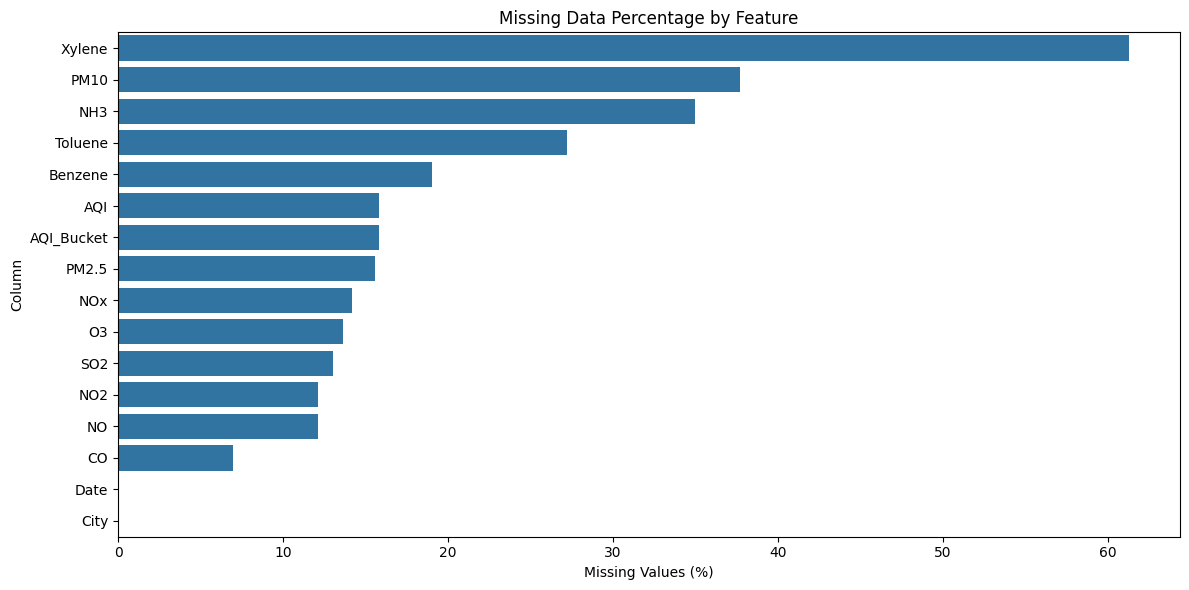

In [23]:
plt.figure(figsize=(12, 6))

missing_percent = (
    df_clean.isnull().mean() * 100
).sort_values(ascending=False)

sns.barplot(
    x=missing_percent.values,
    y=missing_percent.index
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.title("Missing Data Percentage by Feature")
plt.tight_layout()

plt.savefig(
    "../graphs/missing_values_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
pollutant_columns = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene"
]

negative_values = {}

for col in pollutant_columns:
    negative_values[col] = (df_clean[col] < 0).sum()

negative_values = pd.Series(negative_values)

print("Negative values by pollutant:")
print(negative_values)

Negative values by pollutant:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
dtype: int64


In [25]:
outlier_summary = []

for col in pollutant_columns + ["AQI"]:
    
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = (
        (df_clean[col] < lower) |
        (df_clean[col] > upper)
    ).sum()
    
    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": outliers
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,PM2.5,28.820,80.5900,51.7700,-48.83500,158.24500,1982
1,PM10,56.255,149.7450,93.4900,-83.98000,289.98000,1057
2,NO,5.630,19.9500,14.3200,-15.85000,41.43000,2459
3,NO2,11.750,37.6200,25.8700,-27.05500,76.42500,1188
4,NOx,12.820,40.1275,27.3075,-28.14125,81.08875,1868
5,NH3,8.580,30.0200,21.4400,-23.58000,62.18000,1015
6,CO,0.510,1.4500,0.9400,-0.90000,2.86000,2475
7,SO2,5.670,15.2200,9.5500,-8.65500,29.54500,2578
8,O3,18.860,45.5700,26.7100,-21.20500,85.63500,713
9,Benzene,0.120,3.0800,2.9600,-4.32000,7.52000,1668


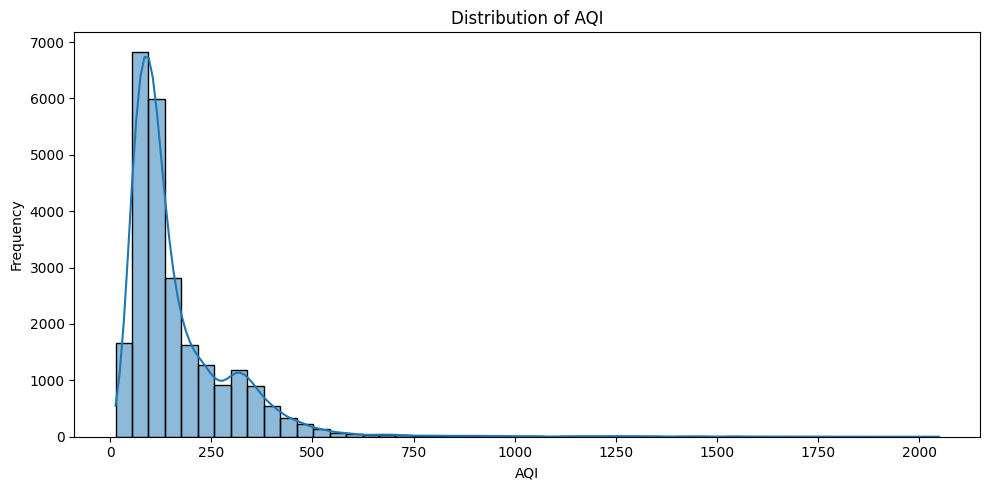

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["AQI"].dropna(),
    bins=50,
    kde=True
)

plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.title("Distribution of AQI")
plt.tight_layout()

plt.savefig(
    "../graphs/aqi_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

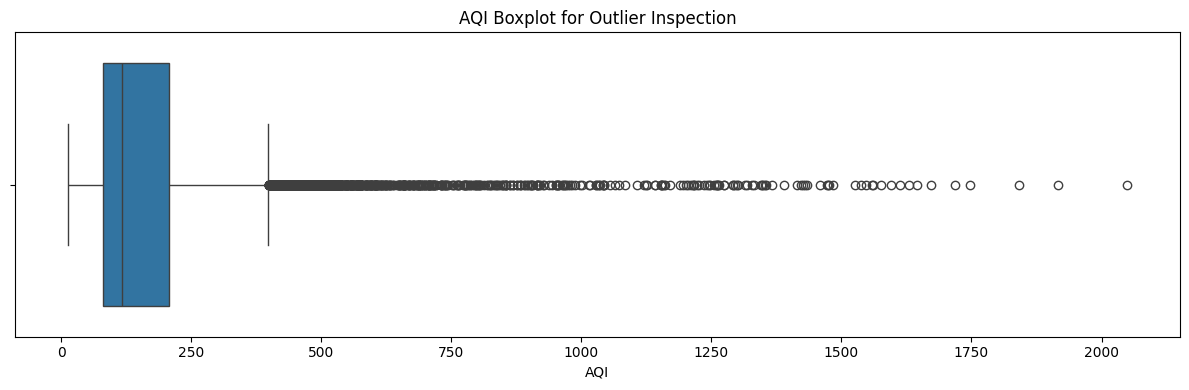

In [27]:
plt.figure(figsize=(12, 4))

sns.boxplot(
    x=df_clean["AQI"]
)

plt.xlabel("AQI")
plt.title("AQI Boxplot for Outlier Inspection")
plt.tight_layout()

plt.savefig(
    "../graphs/aqi_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
print("AQI category distribution:")
print(df_clean["AQI_Bucket"].value_counts(dropna=False))

AQI category distribution:
AQI_Bucket
Moderate        8829
Satisfactory    8224
NaN             4681
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


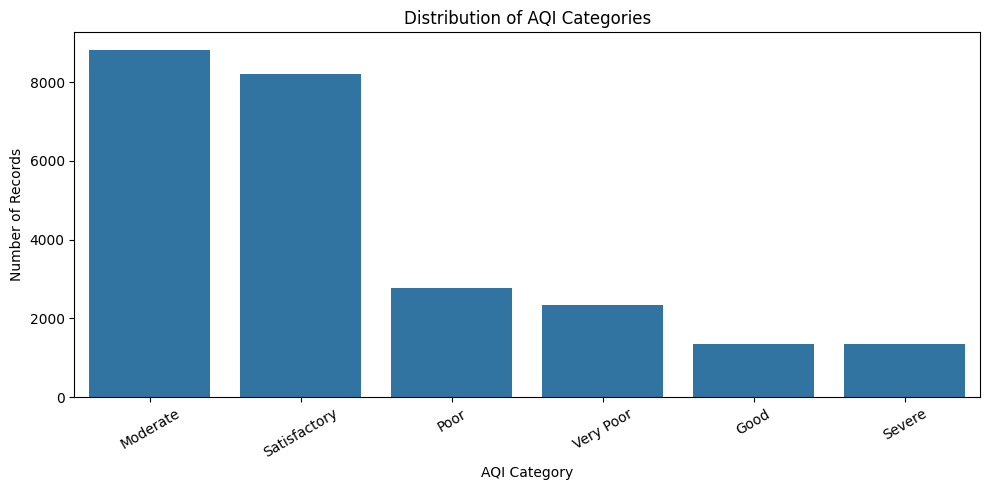

In [29]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_clean,
    x="AQI_Bucket",
    order=df_clean["AQI_Bucket"].value_counts().index
)

plt.xlabel("AQI Category")
plt.ylabel("Number of Records")
plt.title("Distribution of AQI Categories")
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../graphs/aqi_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
city_summary = df_clean.groupby("City").agg(
    Records=("City", "size"),
    AQI_Available=("AQI", "count"),
    AQI_Mean=("AQI", "mean")
).sort_values(
    "Records",
    ascending=False
)

city_summary

,Records,AQI_Available,AQI_Mean
City,,,
Ahmedabad,2009,1334,452.122939
Bengaluru,2009,1910,94.318325
Chennai,2009,1884,114.502654
Mumbai,2009,775,105.352258
Lucknow,2009,1893,217.973059
Delhi,2009,1999,259.487744
Hyderabad,2006,1880,109.207447
Patna,1858,1459,240.782042
Gurugram,1679,1453,225.123882


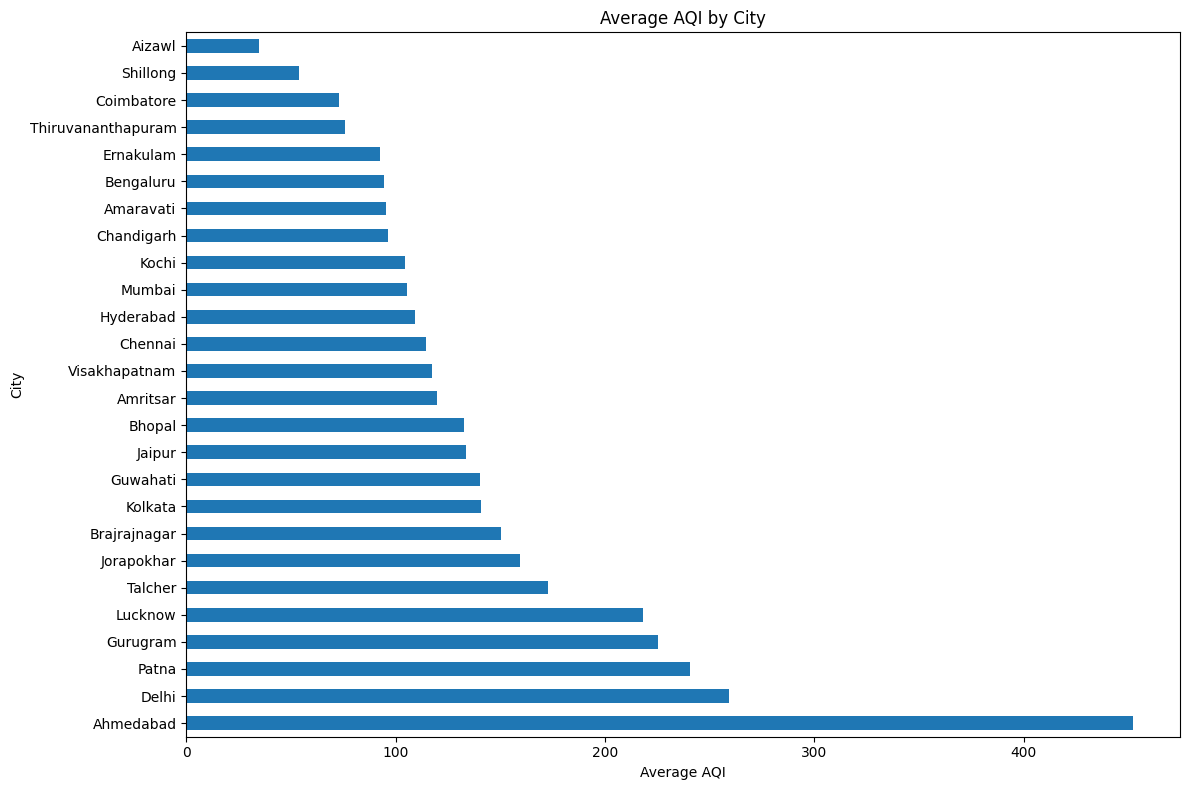

In [31]:
city_aqi = (
    df_clean.groupby("City")["AQI"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 8))

city_aqi.plot(kind="barh")

plt.xlabel("Average AQI")
plt.ylabel("City")
plt.title("Average AQI by City")

plt.tight_layout()

plt.savefig(
    "../graphs/average_aqi_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
monthly_aqi = (
    df_clean
    .set_index("Date")
    .resample("ME")["AQI"]
    .mean()
)

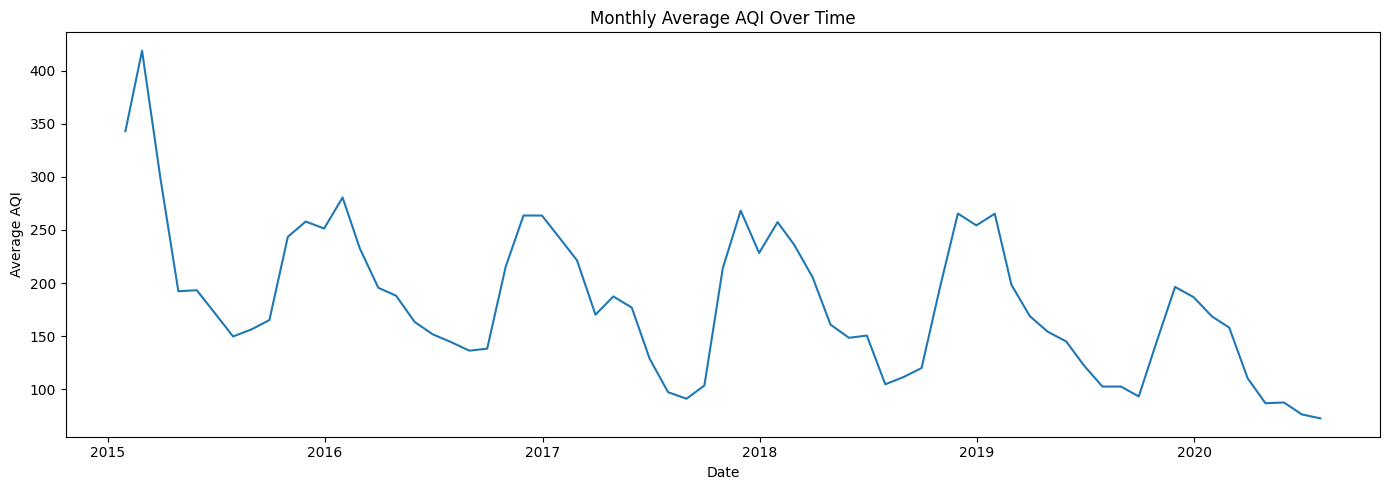

In [33]:
plt.figure(figsize=(14, 5))

plt.plot(monthly_aqi.index, monthly_aqi.values)

plt.xlabel("Date")
plt.ylabel("Average AQI")
plt.title("Monthly Average AQI Over Time")

plt.tight_layout()

plt.savefig(
    "../graphs/monthly_aqi_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Day"] = df_clean["Date"].dt.day
df_clean["DayOfWeek"] = df_clean["Date"].dt.dayofweek

print(df_clean[[
    "Date",
    "Year",
    "Month",
    "Day",
    "DayOfWeek"
]].head())

        Date  Year  Month  Day  DayOfWeek
0 2015-01-01  2015      1    1          3
1 2015-01-02  2015      1    2          4
2 2015-01-03  2015      1    3          5
3 2015-01-04  2015      1    4          6
4 2015-01-05  2015      1    5          0


In [35]:
df_clean.fillna(0)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,Day,DayOfWeek
0,Ahmedabad,2015-01-01,0.00,0.00,0.92,18.22,17.15,0.00,0.92,27.64,133.36,0.00,0.02,0.00,0.0,0,2015,1,1,3
1,Ahmedabad,2015-01-02,0.00,0.00,0.97,15.69,16.46,0.00,0.97,24.55,34.06,3.68,5.50,3.77,0.0,0,2015,1,2,4
2,Ahmedabad,2015-01-03,0.00,0.00,17.40,19.30,29.70,0.00,17.40,29.07,30.70,6.80,16.40,2.25,0.0,0,2015,1,3,5
3,Ahmedabad,2015-01-04,0.00,0.00,1.70,18.48,17.97,0.00,1.70,18.59,36.08,4.43,10.14,1.00,0.0,0,2015,1,4,6
4,Ahmedabad,2015-01-05,0.00,0.00,22.10,21.42,37.76,0.00,22.10,39.33,39.31,7.01,18.89,2.78,0.0,0,2015,1,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good,2020,6,27,5
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory,2020,6,28,6
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory,2020,6,29,0
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory,2020,6,30,1


In [36]:
pollutant_columns = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene"
]

In [37]:
df_clean = df_clean.sort_values(
    ["City", "Date"]
).reset_index(drop=True)

In [38]:
df_clean[pollutant_columns] = (
    df_clean
    .groupby("City")[pollutant_columns]
    .transform(
        lambda group: group.interpolate(
            method="linear",
            limit=7,
            limit_direction="both"
        )
    )
)

In [39]:
remaining_missing = pd.DataFrame({
    "Missing_Count": df_clean.isnull().sum(),
    "Missing_Percentage": (
        df_clean.isnull().mean() * 100
    ).round(2)
})

remaining_missing.sort_values(
    "Missing_Percentage",
    ascending=False
)

,Missing_Count,Missing_Percentage
Xylene,17349,58.75
PM10,10033,33.97
NH3,9252,31.33
Toluene,6995,23.69
AQI_Bucket,4681,15.85
AQI,4681,15.85
Benzene,4376,14.82
PM2.5,3567,12.08
NOx,3394,11.49
O3,2558,8.66


In [40]:
processed_path = "../data/processed/air_quality_cleaned.csv"

df_clean.to_csv(
    processed_path,
    index=False
)

print("Cleaned dataset saved successfully!")
print(processed_path)

Cleaned dataset saved successfully!
../data/processed/air_quality_cleaned.csv


In [41]:
negative_values

PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
dtype: int64

In [42]:
outlier_summary

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,PM2.5,28.820,80.5900,51.7700,-48.83500,158.24500,1982
1,PM10,56.255,149.7450,93.4900,-83.98000,289.98000,1057
2,NO,5.630,19.9500,14.3200,-15.85000,41.43000,2459
3,NO2,11.750,37.6200,25.8700,-27.05500,76.42500,1188
4,NOx,12.820,40.1275,27.3075,-28.14125,81.08875,1868
5,NH3,8.580,30.0200,21.4400,-23.58000,62.18000,1015
6,CO,0.510,1.4500,0.9400,-0.90000,2.86000,2475
7,SO2,5.670,15.2200,9.5500,-8.65500,29.54500,2578
8,O3,18.860,45.5700,26.7100,-21.20500,85.63500,713
9,Benzene,0.120,3.0800,2.9600,-4.32000,7.52000,1668


In [43]:
remaining_missing

,Missing_Count,Missing_Percentage
City,0,0.00
Date,0,0.00
PM2.5,3567,12.08
PM10,10033,33.97
NO,2399,8.12
NO2,2410,8.16
NOx,3394,11.49
NH3,9252,31.33
CO,968,3.28
SO2,2471,8.37


In [44]:
# Check the longest consecutive missing streak for each pollutant

def longest_missing_streak(series):
    missing = series.isna()
    
    groups = missing.ne(missing.shift()).cumsum()
    
    streaks = (
        missing.groupby(groups)
        .sum()
    )
    
    return streaks.max()


gap_summary = []

for col in pollutant_columns:
    max_gap = (
        df_clean
        .groupby("City")[col]
        .apply(longest_missing_streak)
        .max()
    )
    
    gap_summary.append({
        "Feature": col,
        "Longest_Missing_Gap_Days": max_gap
    })

gap_summary = pd.DataFrame(gap_summary)

gap_summary.sort_values(
    "Longest_Missing_Gap_Days",
    ascending=False
)

,Feature,Longest_Missing_Gap_Days
1,PM10,2009
5,NH3,2009
11,Xylene,2009
0,PM2.5,1204
10,Toluene,1169
4,NOx,1169
9,Benzene,1169
3,NO2,1146
2,NO,1104
8,O3,1086


In [45]:
# Missing AQI by city

aqi_missing_city = (
    df_clean
    .groupby("City")["AQI"]
    .apply(lambda x: x.isna().sum())
    .sort_values(ascending=False)
)

aqi_missing_city

City
Mumbai                1234
Ahmedabad              675
Patna                  399
Jorapokhar             398
Visakhapatnam          291
Talcher                227
Gurugram               226
Brajrajnagar           225
Hyderabad              126
Chennai                125
Lucknow                116
Amaravati              110
Shillong               105
Bengaluru               99
Amritsar                95
Kolkata                 60
Thiruvananthapuram      60
Coimbatore              42
Jaipur                  20
Bhopal                  11
Delhi                   10
Ernakulam                9
Guwahati                 7
Chandigarh               5
Kochi                    4
Aizawl                   2
Name: AQI, dtype: int64

In [46]:
# Percentage of AQI missing by city

aqi_missing_percentage = (
    df_clean
    .groupby("City")["AQI"]
    .apply(lambda x: x.isna().mean() * 100)
    .sort_values(ascending=False)
)

aqi_missing_percentage

City
Mumbai                61.423594
Jorapokhar            34.046193
Shillong              33.870968
Ahmedabad             33.598805
Talcher               24.540541
Brajrajnagar          23.987207
Patna                 21.474704
Visakhapatnam         19.904241
Gurugram              13.460393
Amaravati             11.566772
Coimbatore            10.880829
Amritsar               7.780508
Kolkata                7.371007
Hyderabad              6.281157
Chennai                6.222001
Lucknow                5.774017
Ernakulam              5.555556
Thiruvananthapuram     5.395683
Bengaluru              4.927825
Bhopal                 3.806228
Kochi                  2.469136
Jaipur                 1.795332
Aizawl                 1.769912
Chandigarh             1.644737
Guwahati               1.394422
Delhi                  0.497760
Name: AQI, dtype: float64

In [47]:
high_aqi = (
    df_clean[df_clean["AQI"] > 398.5]
    .sort_values("AQI", ascending=False)
)

high_aqi[
    [
        "City",
        "Date",
        "PM2.5",
        "PM10",
        "NO2",
        "NOx",
        "CO",
        "SO2",
        "O3",
        "AQI",
        "AQI_Bucket"
    ]
].head(20)

,City,Date,PM2.5,PM10,NO2,NOx,CO,SO2,O3,AQI,AQI_Bucket
1145,Ahmedabad,2018-02-19,242.66,NaN,199.17,246.03,132.47,127.725,44.060000,2049.0,Severe
1136,Ahmedabad,2018-02-10,185.77,NaN,172.84,186.66,124.01,120.940,40.970000,1917.0,Severe
560,Ahmedabad,2016-07-14,38.13,NaN,48.06,43.98,46.51,23.130,76.352308,1842.0,Severe
1048,Ahmedabad,2017-11-14,207.19,NaN,146.18,159.36,118.02,160.060,37.210000,1747.0,Severe
1463,Ahmedabad,2019-01-03,131.50,NaN,75.82,88.04,119.68,55.290,43.250000,1719.0,Severe
1417,Ahmedabad,2018-11-18,127.46,NaN,77.65,129.43,108.81,63.630,48.320000,1672.0,Severe
1420,Ahmedabad,2018-11-21,86.52,NaN,66.59,81.77,115.87,44.240,36.000000,1646.0,Severe
1407,Ahmedabad,2018-11-08,205.21,NaN,100.87,77.22,93.31,75.950,61.170000,1630.0,Severe
1127,Ahmedabad,2018-02-01,189.12,NaN,178.13,160.97,94.00,168.440,39.060000,1613.0,Severe
1746,Ahmedabad,2019-10-13,194.36,335.86,207.05,223.66,119.30,175.715,27.160000,1595.0,Severe


In [48]:
gap_summary

,Feature,Longest_Missing_Gap_Days
0,PM2.5,1204
1,PM10,2009
2,NO,1104
3,NO2,1146
4,NOx,1169
5,NH3,2009
6,CO,340
7,SO2,1065
8,O3,1086
9,Benzene,1169


In [49]:
aqi_missing_city

City
Mumbai                1234
Ahmedabad              675
Patna                  399
Jorapokhar             398
Visakhapatnam          291
Talcher                227
Gurugram               226
Brajrajnagar           225
Hyderabad              126
Chennai                125
Lucknow                116
Amaravati              110
Shillong               105
Bengaluru               99
Amritsar                95
Kolkata                 60
Thiruvananthapuram      60
Coimbatore              42
Jaipur                  20
Bhopal                  11
Delhi                   10
Ernakulam                9
Guwahati                 7
Chandigarh               5
Kochi                    4
Aizawl                   2
Name: AQI, dtype: int64

In [50]:
high_aqi[
    [
        "City", "Date", "PM2.5", "PM10", "NO2",
        "NOx", "CO", "SO2", "O3", "AQI", "AQI_Bucket"
    ]
].head(20)

,City,Date,PM2.5,PM10,NO2,NOx,CO,SO2,O3,AQI,AQI_Bucket
1145,Ahmedabad,2018-02-19,242.66,NaN,199.17,246.03,132.47,127.725,44.060000,2049.0,Severe
1136,Ahmedabad,2018-02-10,185.77,NaN,172.84,186.66,124.01,120.940,40.970000,1917.0,Severe
560,Ahmedabad,2016-07-14,38.13,NaN,48.06,43.98,46.51,23.130,76.352308,1842.0,Severe
1048,Ahmedabad,2017-11-14,207.19,NaN,146.18,159.36,118.02,160.060,37.210000,1747.0,Severe
1463,Ahmedabad,2019-01-03,131.50,NaN,75.82,88.04,119.68,55.290,43.250000,1719.0,Severe
1417,Ahmedabad,2018-11-18,127.46,NaN,77.65,129.43,108.81,63.630,48.320000,1672.0,Severe
1420,Ahmedabad,2018-11-21,86.52,NaN,66.59,81.77,115.87,44.240,36.000000,1646.0,Severe
1407,Ahmedabad,2018-11-08,205.21,NaN,100.87,77.22,93.31,75.950,61.170000,1630.0,Severe
1127,Ahmedabad,2018-02-01,189.12,NaN,178.13,160.97,94.00,168.440,39.060000,1613.0,Severe
1746,Ahmedabad,2019-10-13,194.36,335.86,207.05,223.66,119.30,175.715,27.160000,1595.0,Severe


In [51]:
# ============================================================
# REBUILD CLEAN DATASET FROM ORIGINAL RAW DATA
# ============================================================

# Reload original dataset so previous interpolation is removed
df_clean = pd.read_csv("../data/raw/air_quality/city_day.csv")

# Convert Date to datetime
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

# Sort chronologically within each city
df_clean = df_clean.sort_values(["City", "Date"]).reset_index(drop=True)

print("Clean dataset rebuilt from RAW data.")
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))

Clean dataset rebuilt from RAW data.
Rows: 29531
Columns: 16


In [52]:
pollutant_columns = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene"
]

print("Pollutant columns:", len(pollutant_columns))

Pollutant columns: 12


In [53]:
# ============================================================
# SHORT-GAP INTERPOLATION
# ============================================================

df_clean = df_clean.sort_values(["City", "Date"]).reset_index(drop=True)

for col in pollutant_columns:
    df_clean[col] = (
        df_clean
        .groupby("City")[col]
        .transform(
            lambda x: x.interpolate(
                method="linear",
                limit=7,
                limit_direction="both"
            )
        )
    )

print("Short-gap interpolation completed.")

Short-gap interpolation completed.


In [54]:
remaining_missing = pd.DataFrame({
    "Missing_Count": df_clean.isnull().sum(),
    "Missing_Percentage": (
        df_clean.isnull().mean() * 100
    ).round(2)
})

remaining_missing

,Missing_Count,Missing_Percentage
City,0,0.00
Date,0,0.00
PM2.5,3567,12.08
PM10,10033,33.97
NO,2399,8.12
NO2,2410,8.16
NOx,3394,11.49
NH3,9252,31.33
CO,968,3.28
SO2,2471,8.37


In [55]:
# ============================================================
# MISSINGNESS INDICATORS
# ============================================================

for col in pollutant_columns:
    df_clean[col + "_Missing"] = df_clean[col].isna().astype(int)

print("Missingness indicators created.")

Missingness indicators created.


In [56]:
missing_summary = pd.DataFrame({
    "Feature": df_clean.columns,
    "Missing_Count": df_clean.isnull().sum().values,
    "Missing_Percentage": (
        df_clean.isnull().mean().values * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    "Missing_Percentage",
    ascending=False
)

missing_summary

,Feature,Missing_Count,Missing_Percentage
13,Xylene,17349,58.75
3,PM10,10033,33.97
7,NH3,9252,31.33
12,Toluene,6995,23.69
15,AQI_Bucket,4681,15.85
14,AQI,4681,15.85
11,Benzene,4376,14.82
2,PM2.5,3567,12.08
6,NOx,3394,11.49
10,O3,2558,8.66


In [57]:
print("Missing AQI:", df_clean["AQI"].isna().sum())

print(
    "Missing AQI percentage:",
    round(df_clean["AQI"].isna().mean() * 100, 2),
    "%"
)

Missing AQI: 4681
Missing AQI percentage: 15.85 %


In [58]:
# ============================================================
# CALENDAR FEATURES
# ============================================================

df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Day"] = df_clean["Date"].dt.day
df_clean["DayOfWeek"] = df_clean["Date"].dt.dayofweek

print(
    df_clean[
        ["Date", "Year", "Month", "Day", "DayOfWeek"]
    ].head()
)

        Date  Year  Month  Day  DayOfWeek
0 2015-01-01  2015      1    1          3
1 2015-01-02  2015      1    2          4
2 2015-01-03  2015      1    3          5
3 2015-01-04  2015      1    4          6
4 2015-01-05  2015      1    5          0


In [59]:
# ============================================================
# PHYSICAL VALIDATION
# ============================================================

negative_values = (
    df_clean[pollutant_columns] < 0
).sum()

print("Negative pollutant values:")
print(negative_values)

Negative pollutant values:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
dtype: int64


In [60]:
duplicate_count = df_clean.duplicated(
    subset=["City", "Date"]
).sum()

print("Duplicate City-Date records:", duplicate_count)

Duplicate City-Date records: 0


In [61]:
df_clean = (
    df_clean
    .sort_values(["City", "Date"])
    .reset_index(drop=True)
)

print("Final sorting completed.")

Final sorting completed.


In [62]:
# ============================================================
# SAVE PROCESSED DATASET
# ============================================================

output_path = "../data/processed/air_quality_cleaned.csv"

df_clean.to_csv(
    output_path,
    index=False
)

print("Processed dataset saved successfully!")
print(output_path)

Processed dataset saved successfully!
../data/processed/air_quality_cleaned.csv


In [63]:
missing_summary

,Feature,Missing_Count,Missing_Percentage
13,Xylene,17349,58.75
3,PM10,10033,33.97
7,NH3,9252,31.33
12,Toluene,6995,23.69
15,AQI_Bucket,4681,15.85
14,AQI,4681,15.85
11,Benzene,4376,14.82
2,PM2.5,3567,12.08
6,NOx,3394,11.49
10,O3,2558,8.66


In [64]:
# Check whether missingness indicators are correct

indicator_check = {}

for col in pollutant_columns:
    indicator_col = col + "_Missing"
    
    indicator_check[col] = {
        "Actual_Missing": df_clean[col].isna().sum(),
        "Indicator_1s": df_clean[indicator_col].sum()
    }

indicator_check = pd.DataFrame(indicator_check).T

indicator_check

,Actual_Missing,Indicator_1s
PM2.5,3567,3567
PM10,10033,10033
NO,2399,2399
NO2,2410,2410
NOx,3394,3394
NH3,9252,9252
CO,968,968
SO2,2471,2471
O3,2558,2558
Benzene,4376,4376


In [65]:
# Verify all missingness indicators

for col in pollutant_columns:
    indicator_col = col + "_Missing"
    
    correct = (
        df_clean[col].isna().astype(int)
        == df_clean[indicator_col]
    ).all()
    
    print(col, ":", "CORRECT" if correct else "ERROR")

PM2.5 : CORRECT
PM10 : CORRECT
NO : CORRECT
NO2 : CORRECT
NOx : CORRECT
NH3 : CORRECT
CO : CORRECT
SO2 : CORRECT
O3 : CORRECT
Benzene : CORRECT
Toluene : CORRECT
Xylene : CORRECT


In [66]:
# AQI distribution summary

print("AQI Statistics")
print("=" * 40)

print("Count:", df["AQI"].count())
print("Mean:", round(df["AQI"].mean(), 2))
print("Median:", round(df["AQI"].median(), 2))
print("Minimum:", df["AQI"].min())
print("Maximum:", df["AQI"].max())

print("\nAQI Category Counts")
print("=" * 40)

print(df["AQI_Bucket"].value_counts(dropna=False))

AQI Statistics
Count: 24850
Mean: 166.46
Median: 118.0
Minimum: 13.0
Maximum: 2049.0

AQI Category Counts
AQI_Bucket
Moderate        8829
Satisfactory    8224
NaN             4681
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


In [67]:
# City-wise AQI analysis

city_aqi = (
    df.groupby("City")["AQI"]
      .agg(["count", "mean", "median", "min", "max"])
      .sort_values("mean", ascending=False)
)

print("City-wise AQI Statistics")
print("=" * 60)

print(city_aqi.round(2))

City-wise AQI Statistics
                    count    mean  median   min     max
City                                                   
Ahmedabad            1334  452.12   384.5  48.0  2049.0
Delhi                1999  259.49   257.0  29.0   716.0
Patna                1459  240.78   215.0  53.0   619.0
Gurugram             1453  225.12   208.0  38.0   891.0
Lucknow              1893  217.97   198.0  39.0   707.0
Talcher               698  172.89   128.5  13.0   570.0
Jorapokhar            771  159.25   133.0  27.0   604.0
Brajrajnagar          713  150.28   122.0  22.0   355.0
Kolkata               754  140.57    94.0  26.0   475.0
Guwahati              495  140.11    98.0  25.0   956.0
Jaipur               1094  133.68   122.0  43.0   457.0
Bhopal                278  132.83   120.0  37.0   312.0
Amritsar             1126  119.92   101.0  20.0   869.0
Visakhapatnam        1171  117.27   106.0  23.0   387.0
Chennai              1884  114.50   100.0  30.0   449.0
Hyderabad            18

In [68]:
# Top 10 cities by average AQI

top_10_cities = city_aqi.head(10)

print("Top 10 Cities by Average AQI")
print("=" * 50)
print(top_10_cities[["count", "mean", "median"]].round(2))

Top 10 Cities by Average AQI
              count    mean  median
City                               
Ahmedabad      1334  452.12   384.5
Delhi          1999  259.49   257.0
Patna          1459  240.78   215.0
Gurugram       1453  225.12   208.0
Lucknow        1893  217.97   198.0
Talcher         698  172.89   128.5
Jorapokhar      771  159.25   133.0
Brajrajnagar    713  150.28   122.0
Kolkata         754  140.57    94.0
Guwahati        495  140.11    98.0


In [69]:
# Monthly AQI trend

monthly_aqi = (
    df.dropna(subset=["AQI"])
      .groupby(df["Date"].dt.to_period("M"))["AQI"]
      .mean()
)

print("Monthly AQI Statistics")
print("=" * 50)
print(monthly_aqi.round(2))

Monthly AQI Statistics
Date
2015-01    343.00
2015-02    418.83
2015-03    298.16
2015-04    192.22
2015-05    193.18
            ...  
2020-03    110.18
2020-04     86.72
2020-05     87.45
2020-06     76.21
2020-07     72.50
Freq: M, Name: AQI, Length: 67, dtype: float64


In [70]:
# Year-wise AQI trend

yearly_aqi = (
    df.dropna(subset=["AQI"])
      .groupby("Year")["AQI"]
      .agg(["count", "mean", "median"])
)

print("Year-wise AQI Statistics")
print("=" * 50)
print(yearly_aqi.round(2))

KeyError: 'Year'

In [71]:
# Create time-based features from Date

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

print("Time features created successfully.")
print(df[["Date", "Year", "Month", "Day", "DayOfWeek"]].head())

Time features created successfully.
        Date  Year  Month  Day  DayOfWeek
0 2015-01-01  2015      1    1          3
1 2015-01-02  2015      1    2          4
2 2015-01-03  2015      1    3          5
3 2015-01-04  2015      1    4          6
4 2015-01-05  2015      1    5          0


In [72]:
# Year-wise AQI trend

yearly_aqi = (
    df.dropna(subset=["AQI"])
      .groupby("Year")["AQI"]
      .agg(["count", "mean", "median"])
)

print("Year-wise AQI Statistics")
print("=" * 50)
print(yearly_aqi.round(2))

Year-wise AQI Statistics
      count    mean  median
Year                       
2015   1827  212.46   175.0
2016   2573  197.15   149.0
2017   3234  181.47   129.0
2018   5724  182.68   124.0
2019   7071  156.52   109.0
2020   4421  113.52    93.0


In [73]:
# Pollutant-AQI correlation analysis

pollutant_columns = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3",
    "Benzene", "Toluene", "Xylene"
]

correlation_with_aqi = (
    df[pollutant_columns + ["AQI"]]
    .corr()["AQI"]
    .drop("AQI")
    .sort_values(ascending=False)
)

print("Pollutant Correlation with AQI")
print("=" * 50)
print(correlation_with_aqi.round(3))

Pollutant Correlation with AQI
PM10       0.803
CO         0.683
PM2.5      0.659
NO2        0.537
SO2        0.491
NOx        0.486
NO         0.452
Toluene    0.280
NH3        0.252
O3         0.199
Xylene     0.166
Benzene    0.044
Name: AQI, dtype: float64


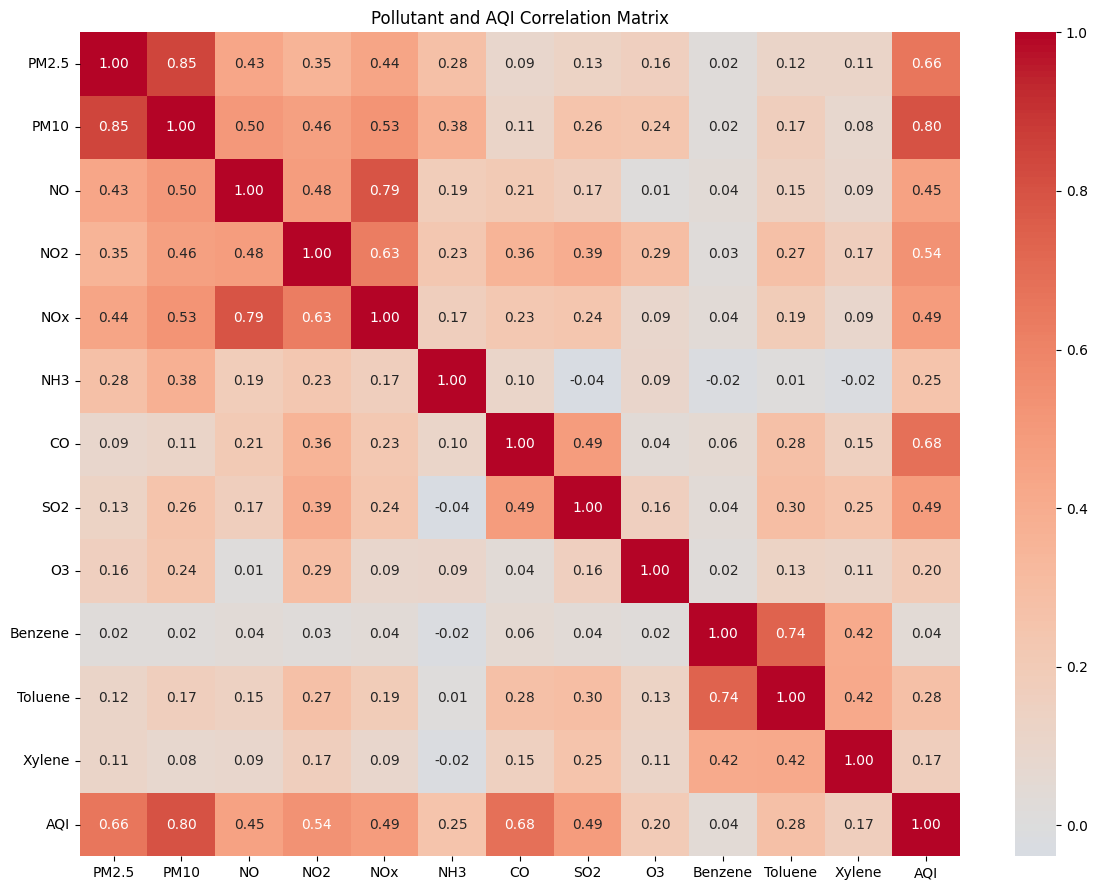

In [74]:
# Correlation matrix of pollutants and AQI

corr_matrix = df[pollutant_columns + ["AQI"]].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Pollutant and AQI Correlation Matrix")
plt.tight_layout()

plt.savefig("../graphs/pollutant_aqi_correlation.png", dpi=300)
plt.show()

In [75]:
# Create a working copy for cleaning

df_clean = df.copy()

print("Original shape:", df.shape)
print("Working copy shape:", df_clean.shape)

Original shape: (29531, 20)
Working copy shape: (29531, 20)


In [76]:
pollutant_columns = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3",
    "Benzene", "Toluene", "Xylene"
]

print("Pollutant columns:", len(pollutant_columns))

Pollutant columns: 12


In [77]:
missing_before = (
    df_clean[pollutant_columns + ["AQI"]]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_percentage_before = (
    df_clean[pollutant_columns + ["AQI"]]
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "Missing_Count": missing_before,
    "Missing_Percentage": missing_percentage_before.round(2)
})

print(missing_summary)

         Missing_Count  Missing_Percentage
Xylene           18109               61.32
PM10             11140               37.72
NH3              10328               34.97
Toluene           8041               27.23
Benzene           5623               19.04
AQI               4681               15.85
PM2.5             4598               15.57
NOx               4185               14.17
O3                4022               13.62
SO2               3854               13.05
NO2               3585               12.14
NO                3582               12.13
CO                2059                6.97


In [78]:
# Check missing runs by pollutant and city

for col in pollutant_columns:
    print(f"\n{col}")
    
    max_gap_by_city = []

    for city, group in df_clean.groupby("City"):
        temp = group.sort_values("Date")[["Date", col]].copy()
        
        missing = temp[col].isna()
        
        if missing.any():
            groups = (missing != missing.shift()).cumsum()
            gaps = missing.groupby(groups).sum()
            max_gap = gaps.max()
        else:
            max_gap = 0
        
        max_gap_by_city.append(max_gap)
    
    print("Maximum missing gap across cities:", int(max(max_gap_by_city)))


PM2.5
Maximum missing gap across cities: 1211

PM10
Maximum missing gap across cities: 2009

NO
Maximum missing gap across cities: 1111

NO2
Maximum missing gap across cities: 1153

NOx
Maximum missing gap across cities: 1169

NH3
Maximum missing gap across cities: 2009

CO
Maximum missing gap across cities: 354

SO2
Maximum missing gap across cities: 1072

O3
Maximum missing gap across cities: 1093

Benzene
Maximum missing gap across cities: 1169

Toluene
Maximum missing gap across cities: 1169

Xylene
Maximum missing gap across cities: 2009


In [81]:
df_clean = df.copy()

In [82]:
# Check the current working dataset

print("df shape:", df.shape)
print("df_clean shape:", df_clean.shape)

print("\nMissing values in df_clean:")
print(df_clean[pollutant_columns + ["AQI"]].isnull().sum())

df shape: (29531, 20)
df_clean shape: (29531, 20)

Missing values in df_clean:
PM2.5       4598
PM10       11140
NO          3582
NO2         3585
NOx         4185
NH3        10328
CO          2059
SO2         3854
O3          4022
Benzene     5623
Toluene     8041
Xylene     18109
AQI         4681
dtype: int64


In [83]:
# Interpolate only short missing gaps within each city
# Maximum 7 consecutive missing days

df_clean = df_clean.sort_values(["City", "Date"]).copy()

for col in pollutant_columns:
    df_clean[col] = (
        df_clean.groupby("City", group_keys=False)[col]
        .transform(
            lambda s: s.interpolate(
                method="linear",
                limit=7,
                limit_area="inside"
            )
        )
    )

print("Short-gap interpolation completed.")

Short-gap interpolation completed.


In [84]:
# Missing values after short-gap interpolation

missing_after = (
    df_clean[pollutant_columns + ["AQI"]]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_after_pct = (
    df_clean[pollutant_columns + ["AQI"]]
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_after_summary = pd.DataFrame({
    "Missing_Count": missing_after,
    "Missing_Percentage": missing_after_pct.round(2)
})

print("Missingness AFTER short-gap interpolation")
print("=" * 60)
print(missing_after_summary)

Missingness AFTER short-gap interpolation
         Missing_Count  Missing_Percentage
Xylene           17526               59.35
PM10             10341               35.02
NH3               9559               32.37
Toluene           7261               24.59
Benzene           4689               15.88
AQI               4681               15.85
PM2.5             3861               13.07
NOx               3597               12.18
O3                2922                9.89
SO2               2818                9.54
NO                2699                9.14
NO2               2699                9.14
CO                1194                4.04


In [85]:
# Missing percentage of each pollutant by city

city_missing = (
    df_clean.groupby("City")[pollutant_columns]
    .apply(lambda x: x.isnull().mean() * 100)
)

print("Missing percentage by city:")
print(city_missing.round(2))

Missing percentage by city:
                    PM2.5    PM10     NO    NO2     NOx     NH3     CO    SO2  \
City                                                                            
Ahmedabad           29.02   79.39  28.42  28.42   27.68  100.00  28.42  29.42   
Aizawl               0.00    0.00   0.00   0.00    0.00    0.00   0.00   0.00   
Amaravati            3.36    3.36   3.36   3.36    3.36    3.36   4.94   3.36   
Amritsar             5.98    0.66   3.77   0.25   21.54    0.08   0.82   5.98   
Bengaluru            4.68   16.18   0.00   0.00    0.00    6.12   0.00   0.00   
Bhopal               0.69    0.69   0.69   0.69    0.69    0.69   0.69   0.69   
Brajrajnagar        11.19   10.45  13.22  13.11   10.02   13.43   8.32   9.06   
Chandigarh           2.30    0.00   0.00   0.00    0.00    0.00   0.00   0.00   
Chennai              4.73   83.82   0.70   0.70    0.70   20.56   0.20   0.70   
Coimbatore           0.26    0.26  13.73   0.00    0.00    8.81   0.00   0.00   


In [86]:
# Average missingness of each pollutant across cities

city_missing_summary = (
    city_missing.mean()
    .sort_values(ascending=False)
    .round(2)
)

print("Average missing percentage across cities:")
print(city_missing_summary)

Average missing percentage across cities:
Xylene     64.51
Toluene    28.02
PM10       21.67
NH3        21.34
Benzene    20.61
O3         10.45
NOx         9.86
PM2.5       9.86
NO2         7.39
NO          7.01
SO2         6.89
CO          3.40
dtype: float64


In [87]:
# Drop Xylene because of very high missingness

df_clean = df_clean.drop(columns=["Xylene"])

print("Xylene removed successfully.")
print("New shape:", df_clean.shape)
print("\nRemaining columns:")
print(df_clean.columns.tolist())

Xylene removed successfully.
New shape: (29531, 19)

Remaining columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI', 'AQI_Bucket', 'Year', 'Month', 'Day', 'DayOfWeek']


In [88]:
# Check missing values after dropping Xylene

missing_now = (
    df_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_now = missing_now[missing_now > 0]

print("Missing values after dropping Xylene:")
print(missing_now)

Missing values after dropping Xylene:
PM10          10341
NH3            9559
Toluene        7261
Benzene        4689
AQI_Bucket     4681
AQI            4681
PM2.5          3861
NOx            3597
O3             2922
SO2            2818
NO             2699
NO2            2699
CO             1194
dtype: int64


In [89]:
# Longest consecutive missing gap for each pollutant

pollutants = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3", "Benzene", "Toluene"
]

def longest_missing_gap(series):
    missing = series.isna()
    
    groups = (~missing).cumsum()
    gaps = missing.groupby(groups).sum()
    
    return int(gaps.max()) if len(gaps) > 0 else 0


gap_summary = []

for col in pollutants:
    max_gap = (
        df_clean.groupby("City")[col]
        .apply(longest_missing_gap)
        .max()
    )
    
    gap_summary.append({
        "Feature": col,
        "Longest_Missing_Gap_Days": max_gap
    })

gap_summary = pd.DataFrame(gap_summary)

gap_summary = gap_summary.sort_values(
    "Longest_Missing_Gap_Days",
    ascending=False
)

print("Longest missing gap by pollutant:")
print(gap_summary)

Longest missing gap by pollutant:
    Feature  Longest_Missing_Gap_Days
1      PM10                      2009
5       NH3                      2009
0     PM2.5                      1211
9   Benzene                      1169
4       NOx                      1169
10  Toluene                      1169
3       NO2                      1153
2        NO                      1111
8        O3                      1093
7       SO2                      1072
6        CO                       347


In [90]:
# ============================================================
# Short-gap interpolation
# ============================================================

# Work on a copy
df_clean = df_clean.copy()

# Sort chronologically within each city
df_clean = df_clean.sort_values(
    ["City", "Date"]
).reset_index(drop=True)

# Pollutant columns used for interpolation
pollutants = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3", "Benzene", "Toluene"
]

# Interpolate only short gaps (maximum 7 consecutive values)
for col in pollutants:
    df_clean[col] = (
        df_clean.groupby("City")[col]
        .transform(
            lambda s: s.interpolate(
                method="linear",
                limit=7,
                limit_area="inside"
            )
        )
    )

print("Short-gap interpolation completed.")

Short-gap interpolation completed.


In [91]:
# ============================================================
# Check missingness after short-gap interpolation
# ============================================================

remaining_missing = (
    df_clean[pollutants]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

remaining_missing_pct = (
    remaining_missing / len(df_clean) * 100
).round(2)

remaining_summary = pd.DataFrame({
    "Missing_Count": remaining_missing,
    "Missing_Percentage": remaining_missing_pct
})

print("Missingness after short-gap interpolation:")
print(remaining_summary)

Missingness after short-gap interpolation:
         Missing_Count  Missing_Percentage
PM10             10101               34.20
NH3               9327               31.58
Toluene           7052               23.88
Benzene           4417               14.96
PM2.5             3655               12.38
NOx               3429               11.61
O3                2577                8.73
SO2               2496                8.45
NO                2439                8.26
NO2               2435                8.25
CO                 979                3.32


In [92]:
# ============================================================
# Create missingness indicators
# ============================================================

for col in pollutants:
    df_clean[col + "_Missing"] = df_clean[col].isnull().astype(int)

print("Missingness indicators created.")

print(
    df_clean[
        [col + "_Missing" for col in pollutants]
    ].sum()
)

Missingness indicators created.
PM2.5_Missing       3655
PM10_Missing       10101
NO_Missing          2439
NO2_Missing         2435
NOx_Missing         3429
NH3_Missing         9327
CO_Missing           979
SO2_Missing         2496
O3_Missing          2577
Benzene_Missing     4417
Toluene_Missing     7052
dtype: int64


In [93]:
# ============================================================
# AQI target availability
# ============================================================

print("AQI missing values:", df_clean["AQI"].isna().sum())
print(
    "AQI missing percentage:",
    round(df_clean["AQI"].isna().mean() * 100, 2),
    "%"
)

print("\nAQI_Bucket missing values:", df_clean["AQI_Bucket"].isna().sum())

AQI missing values: 4681
AQI missing percentage: 15.85 %

AQI_Bucket missing values: 4681


In [94]:
# ============================================================
# Rows with a valid AQI target
# ============================================================

valid_aqi = df_clean["AQI"].notna()

print("Total rows:", len(df_clean))
print("Rows with valid AQI:", valid_aqi.sum())
print("Rows without AQI:", (~valid_aqi).sum())

Total rows: 29531
Rows with valid AQI: 24850
Rows without AQI: 4681


In [95]:
# ============================================================
# Remove AQI_Bucket from ML features
# ============================================================

df_clean = df_clean.drop(columns=["AQI_Bucket"])

print("AQI_Bucket removed.")
print("Current shape:", df_clean.shape)
print("Columns:")
print(df_clean.columns.tolist())

AQI_Bucket removed.
Current shape: (29531, 29)
Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI', 'Year', 'Month', 'Day', 'DayOfWeek', 'PM2.5_Missing', 'PM10_Missing', 'NO_Missing', 'NO2_Missing', 'NOx_Missing', 'NH3_Missing', 'CO_Missing', 'SO2_Missing', 'O3_Missing', 'Benzene_Missing', 'Toluene_Missing']


In [96]:
# ============================================================
# Keep only rows where AQI target is available
# ============================================================

df_ml = df_clean[df_clean["AQI"].notna()].copy()

print("ML dataset created.")
print("Rows:", len(df_ml))
print("Columns:", len(df_ml.columns))
print("Missing AQI:", df_ml["AQI"].isna().sum())

ML dataset created.
Rows: 24850
Columns: 29
Missing AQI: 0


In [97]:
# ============================================================
# Missing pollutant values in ML dataset
# ============================================================

ml_missing = (
    df_ml[pollutants]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

ml_missing_pct = (
    ml_missing / len(df_ml) * 100
).round(2)

ml_missing_summary = pd.DataFrame({
    "Missing_Count": ml_missing,
    "Missing_Percentage": ml_missing_pct
})

print("Missing pollutant values in ML dataset:")
print(ml_missing_summary)

Missing pollutant values in ML dataset:
         Missing_Count  Missing_Percentage
PM10              6785               27.30
NH3               6101               24.55
Toluene           5333               21.46
Benzene           2971               11.96
NOx               1646                6.62
PM2.5              474                1.91
O3                 355                1.43
CO                 232                0.93
SO2                219                0.88
NO                 181                0.73
NO2                134                0.54


In [98]:
# ============================================================
# City-wise missingness in the ML dataset
# ============================================================

top_missing_pollutants = [
    "PM10",
    "NH3",
    "Toluene",
    "Benzene"
]

ml_city_missing = (
    df_ml.groupby("City")[top_missing_pollutants]
    .apply(lambda x: x.isna().mean() * 100)
)

print("City-wise missing percentage:")
print(ml_city_missing.round(2))

City-wise missing percentage:
                      PM10     NH3  Toluene  Benzene
City                                                
Ahmedabad            69.94  100.00     0.75     0.75
Aizawl                0.00    0.00     6.31     6.31
Amaravati             0.00    0.00     0.00     0.00
Amritsar              0.00    0.00     9.77     8.17
Bengaluru            12.51    5.13     0.00     3.77
Bhopal                0.00    0.00   100.00   100.00
Brajrajnagar          0.00    1.96   100.00     1.96
Chandigarh            0.00    0.00     0.00     0.00
Chennai              82.01   19.90     2.34     2.97
Coimbatore            0.00    2.03     0.00     0.00
Delhi                 1.80    0.00     0.00     0.00
Ernakulam             0.00    0.00     0.00     0.00
Gurugram             45.29   91.81    27.53    16.45
Guwahati              0.00    0.00   100.00     0.00
Hyderabad            11.06   11.38     5.11     5.11
Jaipur                0.00    0.00     0.00     0.00
Jorapokhar      

In [99]:
# ============================================================
# Cities with the highest missingness
# ============================================================

for col in top_missing_pollutants:
    print("\n" + "=" * 50)
    print(f"Top cities with missing {col}")
    print("=" * 50)

    print(
        ml_city_missing[col]
        .sort_values(ascending=False)
        .head(10)
        .round(2)
    )


Top cities with missing PM10
City
Lucknow      100.00
Patna         86.91
Chennai       82.01
Ahmedabad     69.94
Gurugram      45.29
Bengaluru     12.51
Hyderabad     11.06
Delhi          1.80
Mumbai         0.65
Aizawl         0.00
Name: PM10, dtype: float64

Top cities with missing NH3
City
Ahmedabad             100.00
Gurugram               91.81
Patna                  86.91
Mumbai                 49.03
Lucknow                46.65
Chennai                19.90
Hyderabad              11.38
Kochi                  10.13
Jorapokhar              9.34
Thiruvananthapuram      8.75
Name: NH3, dtype: float64

Top cities with missing Toluene
City
Brajrajnagar          100.00
Bhopal                100.00
Mumbai                100.00
Thiruvananthapuram    100.00
Jorapokhar            100.00
Guwahati              100.00
Talcher                77.79
Gurugram               27.53
Amritsar                9.77
Aizawl                  6.31
Name: Toluene, dtype: float64

Top cities with missing Benze

In [100]:
# ============================================================
# Check available values for each pollutant by city
# ============================================================

pollutants = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3", "Benzene", "Toluene"
]

# Number of non-missing observations
city_available = df_ml.groupby("City")[pollutants].count()

print("Available observations by city:")
print(city_available)

Available observations by city:
                    PM2.5  PM10    NO   NO2   NOx   NH3    CO   SO2    O3  \
City                                                                        
Ahmedabad            1334   401  1329  1329  1334     0  1329  1316  1329   
Aizawl                111   111   111   111   111   111   111   111   111   
Amaravati             841   841   841   841   841   841   834   841   841   
Amritsar             1073  1126  1090  1126   896  1126  1125  1075  1090   
Bengaluru            1909  1671  1910  1910  1910  1812  1910  1910  1886   
Bhopal                278   278   278   278   278   278   278   278   278   
Brajrajnagar          707   713   689   684   704   699   713   713   707   
Chandigarh            299   299   299   299   299   299   299   299   299   
Chennai              1884   339  1884  1884  1884  1509  1884  1884  1884   
Coimbatore            344   344   294   344   344   337   344   344   344   
Delhi                1999  1963  1999  1999 

In [101]:
# ============================================================
# Count cities where each pollutant is completely unavailable
# ============================================================

for col in pollutants:
    unavailable_cities = (city_available[col] == 0).sum()
    
    print(
        f"{col:10s} -> "
        f"{unavailable_cities} cities have 0 observations"
    )

PM2.5      -> 0 cities have 0 observations
PM10       -> 1 cities have 0 observations
NO         -> 0 cities have 0 observations
NO2        -> 0 cities have 0 observations
NOx        -> 1 cities have 0 observations
NH3        -> 1 cities have 0 observations
CO         -> 0 cities have 0 observations
SO2        -> 0 cities have 0 observations
O3         -> 1 cities have 0 observations
Benzene    -> 4 cities have 0 observations
Toluene    -> 6 cities have 0 observations


In [102]:
# ============================================================
# Hierarchical missing-value imputation
# City median -> pollutant median -> overall median
# ============================================================

pollutants = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3", "Benzene", "Toluene"
]

df_ml_imputed = df_ml.copy()

for col in pollutants:

    # 1. City-level median
    city_median = df_ml_imputed.groupby("City")[col].transform("median")
    df_ml_imputed[col] = df_ml_imputed[col].fillna(city_median)

    # 2. Pollutant-level median
    pollutant_median = df_ml_imputed[col].median()
    df_ml_imputed[col] = df_ml_imputed[col].fillna(pollutant_median)

    # 3. Final overall median fallback
    overall_median = df_ml_imputed[col].median()
    df_ml_imputed[col] = df_ml_imputed[col].fillna(overall_median)


print("Hierarchical imputation completed.")
print("Remaining missing pollutant values:")
print(df_ml_imputed[pollutants].isna().sum())

Hierarchical imputation completed.
Remaining missing pollutant values:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
dtype: int64


In [103]:
# ============================================================
# Verify imputation
# ============================================================

remaining_missing = df_ml_imputed[pollutants].isna().sum()

print("Remaining missing values:")
print(remaining_missing)

print("\nTotal remaining missing pollutant values:",
      remaining_missing.sum())

Remaining missing values:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
dtype: int64

Total remaining missing pollutant values: 0


In [104]:
# ============================================================
# Validate pollutant values after imputation
# Check for negative and extreme values
# ============================================================

print("Negative values after imputation:")
print((df_ml_imputed[pollutants] < 0).sum())

print("\nSummary statistics after imputation:")
print(df_ml_imputed[pollutants].describe().T[
    ["count", "mean", "50%", "min", "max"]
].round(2))

Negative values after imputation:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
dtype: int64

Summary statistics after imputation:
           count    mean     50%   min     max
PM2.5    24850.0   67.10   49.24  0.04  914.94
PM10     24850.0  113.75  100.36  0.03  917.08
NO       24850.0   17.75    9.95  0.03  390.68
NO2      24850.0   28.75   21.87  0.01  362.21
NOx      24850.0   31.68   23.66  0.00  378.24
NH3      24850.0   23.31   17.17  0.01  352.89
CO       24850.0    2.32    0.92  0.00  175.81
SO2      24850.0   14.42    9.22  0.01  186.08
O3       24850.0   34.90   31.31  0.01  257.73
Benzene  24850.0    3.36    1.29  0.00  455.03
Toluene  24850.0    8.27    3.52  0.00  454.85


In [105]:
# ============================================================
# Check whether imputation changed the dataset size
# ============================================================

print("Original ML dataset shape:", df_ml.shape)
print("Imputed ML dataset shape:", df_ml_imputed.shape)

print("\nRows:", len(df_ml_imputed))
print("Columns:", len(df_ml_imputed.columns))

Original ML dataset shape: (24850, 29)
Imputed ML dataset shape: (24850, 29)

Rows: 24850
Columns: 29


In [106]:
# ============================================================
# Outlier summary after imputation
# ============================================================

outlier_summary_after = []

for col in pollutants:
    Q1 = df_ml_imputed[col].quantile(0.25)
    Q3 = df_ml_imputed[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df_ml_imputed[col] < lower_bound) |
        (df_ml_imputed[col] > upper_bound)
    ).sum()

    outlier_summary_after.append({
        "Feature": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower_Bound": round(lower_bound, 2),
        "Upper_Bound": round(upper_bound, 2),
        "Outlier_Count": int(outlier_count),
        "Outlier_Percentage": round(
            outlier_count / len(df_ml_imputed) * 100, 2
        )
    })

outlier_summary_after = pd.DataFrame(outlier_summary_after)

print("Outlier summary after imputation:")
print(outlier_summary_after)

Outlier summary after imputation:
    Feature     Q1      Q3    IQR  Lower_Bound  Upper_Bound  Outlier_Count  \
0     PM2.5  29.31   79.67  50.36       -46.23       155.20           1996   
1      PM10  58.17  134.70  76.52       -56.61       249.48           1550   
2        NO   5.70   20.08  14.38       -15.87        41.65           2390   
3       NO2  11.80   37.97  26.17       -27.45        77.22           1104   
4       NOx  13.87   38.34  24.47       -22.83        75.04           1918   
5       NH3  10.77   29.63  18.86       -17.52        57.91           1206   
6        CO   0.57    1.47   0.90        -0.78         2.82           2288   
7       SO2   5.73   15.21   9.48        -8.49        29.43           2452   
8        O3  19.43   45.78  26.35       -20.10        85.30            734   
9   Benzene   0.31    3.04   2.72        -3.78         7.12           1854   
10  Toluene   1.26    7.65   6.39        -8.33        17.24           3126   

    Outlier_Percentage  
0   

In [107]:
# ============================================================
# Imputation impact
# ============================================================

print("Number of values imputed per pollutant:")
print(
    df_ml[pollutants].isna().sum()
    .sort_values(ascending=False)
)

Number of values imputed per pollutant:
PM10       6785
NH3        6101
Toluene    5333
Benzene    2971
NOx        1646
PM2.5       474
O3          355
CO          232
SO2         219
NO          181
NO2         134
dtype: int64


In [108]:
# ============================================================
# FINAL DATA QUALITY VALIDATION
# ============================================================

print("=" * 60)
print("FINAL DATA QUALITY VALIDATION")
print("=" * 60)

# 1. Shape
print("\n1. Dataset shape:")
print("Rows:", len(df_ml_imputed))
print("Columns:", len(df_ml_imputed.columns))

# 2. Missing values
print("\n2. Missing values:")
print("Total missing values:",
      df_ml_imputed.isna().sum().sum())

# 3. Duplicate rows
print("\n3. Duplicate rows:")
print("Duplicate rows:", df_ml_imputed.duplicated().sum())

# 4. Negative pollutant values
print("\n4. Negative pollutant values:")
print("Total negative values:",
      (df_ml_imputed[pollutants] < 0).sum().sum())

# 5. Infinite values
print("\n5. Infinite values:")
print(
    "Total infinite values:",
    np.isinf(
        df_ml_imputed[pollutants].select_dtypes(include=np.number)
    ).sum().sum()
)

# 6. AQI target
print("\n6. AQI target:")
print("Missing AQI:", df_ml_imputed["AQI"].isna().sum())
print("Minimum AQI:", df_ml_imputed["AQI"].min())
print("Maximum AQI:", df_ml_imputed["AQI"].max())

# 7. Date range
print("\n7. Date range:")
print("Start:", df_ml_imputed["Date"].min())
print("End:", df_ml_imputed["Date"].max())

# 8. Cities
print("\n8. Number of cities:")
print(df_ml_imputed["City"].nunique())

print("\n" + "=" * 60)
print("VALIDATION COMPLETE")
print("=" * 60)

FINAL DATA QUALITY VALIDATION

1. Dataset shape:
Rows: 24850
Columns: 29

2. Missing values:
Total missing values: 0

3. Duplicate rows:
Duplicate rows: 0

4. Negative pollutant values:
Total negative values: 0

5. Infinite values:
Total infinite values: 0

6. AQI target:
Missing AQI: 0
Minimum AQI: 13.0
Maximum AQI: 2049.0

7. Date range:
Start: 2015-01-01 00:00:00
End: 2020-07-01 00:00:00

8. Number of cities:
26

VALIDATION COMPLETE


In [109]:
# ============================================================
# Save final cleaned ML dataset
# ============================================================

output_path = "../data/processed/AeroPure_ML_clean.csv"

df_ml_imputed.to_csv(output_path, index=False)

print("Cleaned ML dataset saved successfully.")
print("File:", output_path)
print("Shape:", df_ml_imputed.shape)

Cleaned ML dataset saved successfully.
File: ../data/processed/AeroPure_ML_clean.csv
Shape: (24850, 29)


In [110]:
import os

print("File exists:", os.path.exists(output_path))

if os.path.exists(output_path):
    print("File size (MB):",
          round(os.path.getsize(output_path) / (1024**2), 2))

File exists: True
File size (MB): 2.93


In [111]:
# ============================================================
# Pollutant-AQI correlation analysis
# ============================================================

correlation_data = df_ml_imputed[pollutants + ["AQI"]]

correlation_matrix = correlation_data.corr()

print("Correlation of pollutants with AQI:")
print(
    correlation_matrix["AQI"]
    .drop("AQI")
    .sort_values(ascending=False)
    .round(3)
)

Correlation of pollutants with AQI:
CO         0.677
PM2.5      0.654
NO2        0.534
PM10       0.494
SO2        0.489
NOx        0.469
NO         0.437
Toluene    0.277
O3         0.197
NH3        0.099
Benzene    0.047
Name: AQI, dtype: float64


In [112]:
# ============================================================
# Full correlation matrix
# ============================================================

print("Full pollutant-AQI correlation matrix:")
print(correlation_matrix.round(3))

Full pollutant-AQI correlation matrix:
         PM2.5   PM10     NO    NO2    NOx    NH3     CO    SO2     O3  \
PM2.5    1.000  0.569  0.443  0.365  0.411  0.182  0.093  0.128  0.167   
PM10     0.569  1.000  0.454  0.374  0.459  0.128  0.036  0.190  0.210   
NO       0.443  0.454  1.000  0.458  0.768  0.132  0.210  0.179  0.027   
NO2      0.365  0.374  0.458  1.000  0.620  0.127  0.371  0.420  0.293   
NOx      0.411  0.459  0.768  0.620  1.000  0.091  0.249  0.238  0.094   
NH3      0.182  0.128  0.132  0.127  0.091  1.000 -0.022 -0.082  0.071   
CO       0.093  0.036  0.210  0.371  0.249 -0.022  1.000  0.499  0.039   
SO2      0.128  0.190  0.179  0.420  0.238 -0.082  0.499  1.000  0.168   
O3       0.167  0.210  0.027  0.293  0.094  0.071  0.039  0.168  1.000   
Benzene  0.024  0.011  0.033  0.030  0.043 -0.007  0.050  0.032  0.017   
Toluene  0.125  0.122  0.131  0.283  0.183  0.000  0.279  0.276  0.135   
AQI      0.654  0.494  0.437  0.534  0.469  0.099  0.677  0.489  0.197   

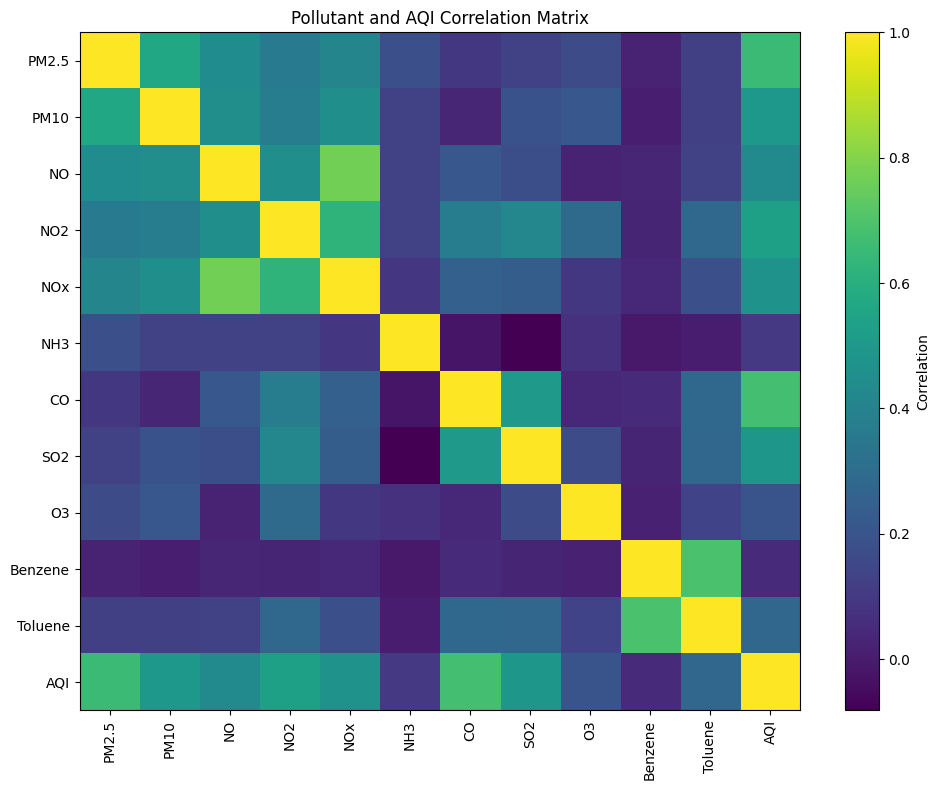

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Pollutant and AQI Correlation Matrix")
plt.tight_layout()

plt.savefig(
    "../graphs/pollutant_aqi_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [114]:
# ============================================================
# Exact pollutant-AQI correlations
# ============================================================

aqi_correlations = (
    correlation_matrix["AQI"]
    .drop("AQI")
    .sort_values(ascending=False)
)

print("Pollutant correlation with AQI")
print("=" * 50)
print(aqi_correlations.round(3))

Pollutant correlation with AQI
CO         0.677
PM2.5      0.654
NO2        0.534
PM10       0.494
SO2        0.489
NOx        0.469
NO         0.437
Toluene    0.277
O3         0.197
NH3        0.099
Benzene    0.047
Name: AQI, dtype: float64


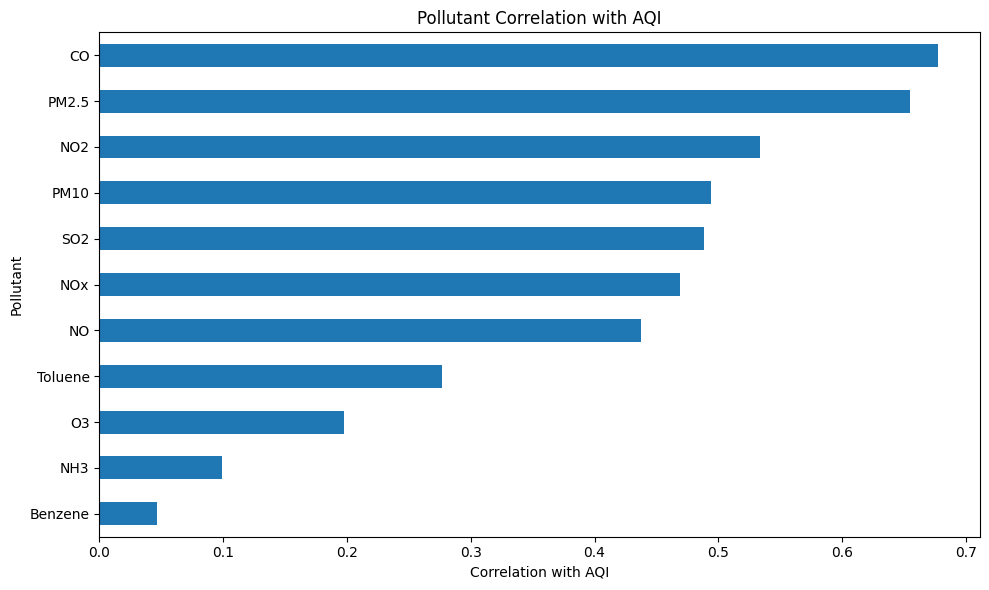

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

aqi_correlations.sort_values().plot(kind="barh")

plt.xlabel("Correlation with AQI")
plt.ylabel("Pollutant")
plt.title("Pollutant Correlation with AQI")
plt.tight_layout()

plt.savefig(
    "../graphs/pollutant_aqi_correlation_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [116]:
# ============================================================
# FINAL W2: DATA LEAKAGE CHECK
# ============================================================

target = "AQI"

print("=" * 60)
print("FINAL DATA LEAKAGE CHECK")
print("=" * 60)

# 1. Check whether AQI_Bucket still exists
print("\n1. Target-derived columns:")
target_derived = [
    col for col in df_ml_imputed.columns
    if "AQI" in col.upper() and col != "AQI"
]

print(target_derived)

# 2. Check whether the target is accidentally duplicated
print("\n2. Possible duplicate target columns:")

for col in df_ml_imputed.columns:
    if col != target:
        if df_ml_imputed[col].equals(df_ml_imputed[target]):
            print("WARNING:", col, "is identical to AQI")

# 3. Check missingness indicators
print("\n3. Missingness indicator columns:")
missing_indicators = [
    col for col in df_ml_imputed.columns
    if col.endswith("_Missing")
]

print(missing_indicators)

# 4. Check whether any feature has perfect correlation with AQI
print("\n4. Features with very high correlation to AQI:")

numeric_df = df_ml_imputed.select_dtypes(include="number")

corr_with_aqi = (
    numeric_df.corr()["AQI"]
    .drop("AQI")
    .abs()
    .sort_values(ascending=False)
)

print(corr_with_aqi.head(10).round(3))

print("\n" + "=" * 60)
print("LEAKAGE CHECK COMPLETE")
print("=" * 60)

FINAL DATA LEAKAGE CHECK

1. Target-derived columns:
[]

2. Possible duplicate target columns:

3. Missingness indicator columns:
['PM2.5_Missing', 'PM10_Missing', 'NO_Missing', 'NO2_Missing', 'NOx_Missing', 'NH3_Missing', 'CO_Missing', 'SO2_Missing', 'O3_Missing', 'Benzene_Missing', 'Toluene_Missing']

4. Features with very high correlation to AQI:
CO              0.677
PM2.5           0.654
NO2             0.534
PM10            0.494
SO2             0.489
NOx             0.469
NO              0.437
NH3_Missing     0.369
PM10_Missing    0.297
Toluene         0.277
Name: AQI, dtype: float64

LEAKAGE CHECK COMPLETE


In [117]:
# ============================================================
# FINAL W2 -> LEAKAGE-SAFE TIME-BASED SPLIT
# ============================================================

import pandas as pd

# Make sure Date is datetime
df_ml_imputed["Date"] = pd.to_datetime(df_ml_imputed["Date"])

# Sort chronologically
df_ml_imputed = df_ml_imputed.sort_values(
    ["Date", "City"]
).reset_index(drop=True)

# 80% train / 20% test based on time
split_date = df_ml_imputed["Date"].quantile(0.80)

train_data = df_ml_imputed[
    df_ml_imputed["Date"] <= split_date
].copy()

test_data = df_ml_imputed[
    df_ml_imputed["Date"] > split_date
].copy()

print("=" * 60)
print("TIME-BASED TRAIN / TEST SPLIT")
print("=" * 60)

print("\nSplit date:", split_date)

print("\nTraining data:")
print("Rows:", len(train_data))
print("Start:", train_data["Date"].min())
print("End:", train_data["Date"].max())

print("\nTesting data:")
print("Rows:", len(test_data))
print("Start:", test_data["Date"].min())
print("End:", test_data["Date"].max())

print("\nTotal rows:", len(train_data) + len(test_data))

TIME-BASED TRAIN / TEST SPLIT

Split date: 2019-12-06 00:00:00

Training data:
Rows: 19882
Start: 2015-01-01 00:00:00
End: 2019-12-06 00:00:00

Testing data:
Rows: 4968
Start: 2019-12-07 00:00:00
End: 2020-07-01 00:00:00

Total rows: 24850


In [118]:
# ============================================================
# LEAKAGE-SAFE RAW ML DATASET
# ============================================================

# Start from the dataset BEFORE pollutant imputation
df_ml_raw = df_ml.copy()

# Ensure chronological ordering
df_ml_raw["Date"] = pd.to_datetime(df_ml_raw["Date"])

df_ml_raw = (
    df_ml_raw
    .sort_values(["Date", "City"])
    .reset_index(drop=True)
)

# Same chronological split
split_date = pd.Timestamp("2019-12-06")

train_raw = df_ml_raw[
    df_ml_raw["Date"] <= split_date
].copy()

test_raw = df_ml_raw[
    df_ml_raw["Date"] > split_date
].copy()

print("=" * 60)
print("LEAKAGE-SAFE RAW SPLIT")
print("=" * 60)

print("\nTrain shape:", train_raw.shape)
print("Test shape :", test_raw.shape)

print("\nTrain period:")
print(train_raw["Date"].min(), "to", train_raw["Date"].max())

print("\nTest period:")
print(test_raw["Date"].min(), "to", test_raw["Date"].max())

print("\nMissing AQI:")
print("Train:", train_raw["AQI"].isna().sum())
print("Test :", test_raw["AQI"].isna().sum())

LEAKAGE-SAFE RAW SPLIT

Train shape: (19882, 29)
Test shape : (4968, 29)

Train period:
2015-01-01 00:00:00 to 2019-12-06 00:00:00

Test period:
2019-12-07 00:00:00 to 2020-07-01 00:00:00

Missing AQI:
Train: 0
Test : 0


In [119]:
# ============================================================
# LEAKAGE-SAFE HIERARCHICAL IMPUTATION
# ============================================================

pollutants = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3", "Benzene", "Toluene"
]

# Make copies
train_imp = train_raw.copy()
test_imp = test_raw.copy()

# ------------------------------------------------------------
# 1. Re-create missingness indicators BEFORE imputation
# ------------------------------------------------------------

for col in pollutants:
    indicator = col + "_Missing"

    train_imp[indicator] = train_imp[col].isna().astype(int)
    test_imp[indicator] = test_imp[col].isna().astype(int)


# ------------------------------------------------------------
# 2. Calculate CITY-WISE medians using TRAIN ONLY
# ------------------------------------------------------------

train_city_medians = (
    train_imp
    .groupby("City")[pollutants]
    .median()
)

# ------------------------------------------------------------
# 3. Calculate GLOBAL TRAIN medians
# ------------------------------------------------------------

train_global_medians = train_imp[pollutants].median()

# ------------------------------------------------------------
# 4. Apply city median -> global train median
# ------------------------------------------------------------

for col in pollutants:

    # TRAIN
    train_imp[col] = train_imp[col].fillna(
        train_imp["City"].map(train_city_medians[col])
    )

    train_imp[col] = train_imp[col].fillna(
        train_global_medians[col]
    )

    # TEST
    test_imp[col] = test_imp[col].fillna(
        test_imp["City"].map(train_city_medians[col])
    )

    test_imp[col] = test_imp[col].fillna(
        train_global_medians[col]
    )


print("=" * 60)
print("LEAKAGE-SAFE IMPUTATION COMPLETE")
print("=" * 60)

print("\nRemaining missing pollutant values:")

print("\nTRAIN:")
print(train_imp[pollutants].isna().sum())

print("\nTEST:")
print(test_imp[pollutants].isna().sum())

LEAKAGE-SAFE IMPUTATION COMPLETE

Remaining missing pollutant values:

TRAIN:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
dtype: int64

TEST:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
dtype: int64


In [120]:
# ============================================================
# VERIFY LEAKAGE-SAFE IMPUTATION
# ============================================================

print("=" * 60)
print("IMPUTATION VERIFICATION")
print("=" * 60)

print("\nOriginal train shape :", train_raw.shape)
print("Imputed train shape :", train_imp.shape)

print("\nOriginal test shape  :", test_raw.shape)
print("Imputed test shape  :", test_imp.shape)

print("\nTrain rows changed:",
      len(train_raw) - len(train_imp))

print("Test rows changed:",
      len(test_raw) - len(test_imp))

print("\nTotal remaining missing pollutants:")

print(
    "Train:",
    train_imp[pollutants].isna().sum().sum()
)

print(
    "Test :",
    test_imp[pollutants].isna().sum().sum()
)

IMPUTATION VERIFICATION

Original train shape : (19882, 29)
Imputed train shape : (19882, 29)

Original test shape  : (4968, 29)
Imputed test shape  : (4968, 29)

Train rows changed: 0
Test rows changed: 0

Total remaining missing pollutants:
Train: 0
Test : 0


In [121]:
# ============================================================
# W3 - STEP 1: FEATURE / TARGET PREPARATION
# ============================================================

target = "AQI"

# Pollutant features
pollutant_features = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3", "Benzene", "Toluene"
]

# Missingness indicators
missing_features = [
    col for col in train_imp.columns
    if col.endswith("_Missing")
]

# Time features
time_features = [
    "Year",
    "Month",
    "Day",
    "DayOfWeek"
]

# Combine features
feature_columns = (
    pollutant_features
    + missing_features
    + time_features
)

print("=" * 60)
print("W3 FEATURE PREPARATION")
print("=" * 60)

print("\nNumber of pollutant features:", len(pollutant_features))
print("Number of missing indicators:", len(missing_features))
print("Number of time features:", len(time_features))
print("Total features:", len(feature_columns))

print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

print("\nTarget:", target)

W3 FEATURE PREPARATION

Number of pollutant features: 11
Number of missing indicators: 11
Number of time features: 4
Total features: 26

Features:
- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- CO
- SO2
- O3
- Benzene
- Toluene
- PM2.5_Missing
- PM10_Missing
- NO_Missing
- NO2_Missing
- NOx_Missing
- NH3_Missing
- CO_Missing
- SO2_Missing
- O3_Missing
- Benzene_Missing
- Toluene_Missing
- Year
- Month
- Day
- DayOfWeek

Target: AQI


In [122]:
# ============================================================
# CREATE X / Y
# ============================================================

X_train = train_imp[feature_columns].copy()
X_test = test_imp[feature_columns].copy()

y_train = train_imp[target].copy()
y_test = test_imp[target].copy()

print("\n" + "=" * 60)
print("ML DATASET")
print("=" * 60)

print("\nX_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nTarget statistics:")

print("\nTRAIN:")
print(y_train.describe().round(2))

print("\nTEST:")
print(y_test.describe().round(2))


ML DATASET

X_train shape: (19882, 26)
X_test shape : (4968, 26)

y_train shape: (19882,)
y_test shape : (4968,)

Target statistics:

TRAIN:
count    19882.00
mean       177.60
std        148.65
min         13.00
25%         86.00
50%        124.00
75%        229.00
max       2049.00
Name: AQI, dtype: float64

TEST:
count    4968.00
mean      121.90
std        90.01
min        14.00
25%        68.00
50%        97.00
75%       142.00
max      1291.00
Name: AQI, dtype: float64


In [123]:
# ============================================================
# W3 — BASELINE MODEL EVALUATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 60)
print("W3 BASELINE MODEL EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Naive baseline: predict the training mean for every test row
# ------------------------------------------------------------

baseline_prediction = np.full(
    shape=len(y_test),
    fill_value=y_train.mean()
)

baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_prediction))
baseline_r2 = r2_score(y_test, baseline_prediction)

print("\nBASELINE: Training Mean Predictor")
print("-" * 40)
print("Training AQI mean:", round(y_train.mean(), 2))
print("MAE :", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))
print("R²  :", round(baseline_r2, 4))

W3 BASELINE MODEL EVALUATION

BASELINE: Training Mean Predictor
----------------------------------------
Training AQI mean: 177.6
MAE : 89.64
RMSE: 105.84
R²  : -0.383


In [124]:
# ============================================================
# Linear Regression Baseline
# ============================================================

from sklearn.linear_model import LinearRegression

print("=" * 60)
print("LINEAR REGRESSION")
print("=" * 60)

# Create model
linear_model = LinearRegression()

# Train ONLY on training data
linear_model.fit(X_train, y_train)

# Predict test data
y_pred_linear = linear_model.predict(X_test)

# Evaluate
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))

LINEAR REGRESSION
MAE : 22.39
RMSE: 34.19
R²  : 0.8557


In [125]:
# ============================================================
# Baseline Comparison
# ============================================================

baseline_results = pd.DataFrame({
    "Model": [
        "Mean Baseline",
        "Linear Regression"
    ],
    "MAE": [
        baseline_mae,
        linear_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2
    ]
})

print("\nBaseline Model Comparison")
print("=" * 60)
print(baseline_results.round(4))


Baseline Model Comparison
               Model      MAE      RMSE      R2
0      Mean Baseline  89.6356  105.8389 -0.3830
1  Linear Regression  22.3880   34.1924  0.8557


In [126]:
# Save baseline results
baseline_results.to_csv(
    "../data/processed/W3_baseline_results.csv",
    index=False
)

print("\nBaseline results saved successfully.")


Baseline results saved successfully.


In [127]:
# ============================================================
# W3 — RANDOM FOREST REGRESSOR
# ============================================================

from sklearn.ensemble import RandomForestRegressor

print("=" * 60)
print("RANDOM FOREST REGRESSION")
print("=" * 60)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Train only on training data
rf_model.fit(X_train, y_train)

# Predict test data
y_pred_rf = rf_model.predict(X_test)

# Evaluation
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

RANDOM FOREST REGRESSION
MAE : 16.93
RMSE: 27.54
R²  : 0.9063


In [128]:
# ============================================================
# W3 — GRADIENT BOOSTING REGRESSOR
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor

print("=" * 60)
print("GRADIENT BOOSTING REGRESSION")
print("=" * 60)

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train only on training data
gb_model.fit(X_train, y_train)

# Predict test data
y_pred_gb = gb_model.predict(X_test)

# Evaluation
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)

print("MAE :", round(gb_mae, 2))
print("RMSE:", round(gb_rmse, 2))
print("R²  :", round(gb_r2, 4))

GRADIENT BOOSTING REGRESSION
MAE : 18.11
RMSE: 28.24
R²  : 0.9015


In [129]:
# ============================================================
# W3 — COMPLETE MODEL COMPARISON
# ============================================================

model_results = pd.DataFrame({
    "Model": [
        "Mean Baseline",
        "Linear Regression",
        "Gradient Boosting",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        gb_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        gb_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        gb_r2,
        rf_r2
    ]
})

model_results = model_results.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

print("=" * 60)
print("W3 MODEL COMPARISON")
print("=" * 60)

print(model_results.round(4))

W3 MODEL COMPARISON
               Model      MAE      RMSE      R2
0      Random Forest  16.9265   27.5445  0.9063
1  Gradient Boosting  18.1073   28.2425  0.9015
2  Linear Regression  22.3880   34.1924  0.8557
3      Mean Baseline  89.6356  105.8389 -0.3830


In [130]:
# Save model comparison
model_results.to_csv(
    "../data/processed/W3_model_comparison.csv",
    index=False
)

print("\nModel comparison saved successfully.")


Model comparison saved successfully.


In [131]:
# ============================================================
# W3 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("=" * 60)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

print(feature_importance.round(4))

RANDOM FOREST FEATURE IMPORTANCE
            Feature  Importance
0             PM2.5      0.4768
1                CO      0.3785
2                NO      0.0363
3              PM10      0.0317
4                O3      0.0138
5               NOx      0.0104
6               SO2      0.0091
7               NO2      0.0079
8               Day      0.0065
9           Toluene      0.0060
10             Year      0.0050
11          Benzene      0.0049
12            Month      0.0040
13              NH3      0.0031
14        DayOfWeek      0.0028
15     PM10_Missing      0.0010
16      NH3_Missing      0.0005
17      NOx_Missing      0.0002
18      SO2_Missing      0.0002
19       CO_Missing      0.0002
20  Benzene_Missing      0.0002
21      NO2_Missing      0.0002
22  Toluene_Missing      0.0002
23       O3_Missing      0.0001
24       NO_Missing      0.0001
25    PM2.5_Missing      0.0001


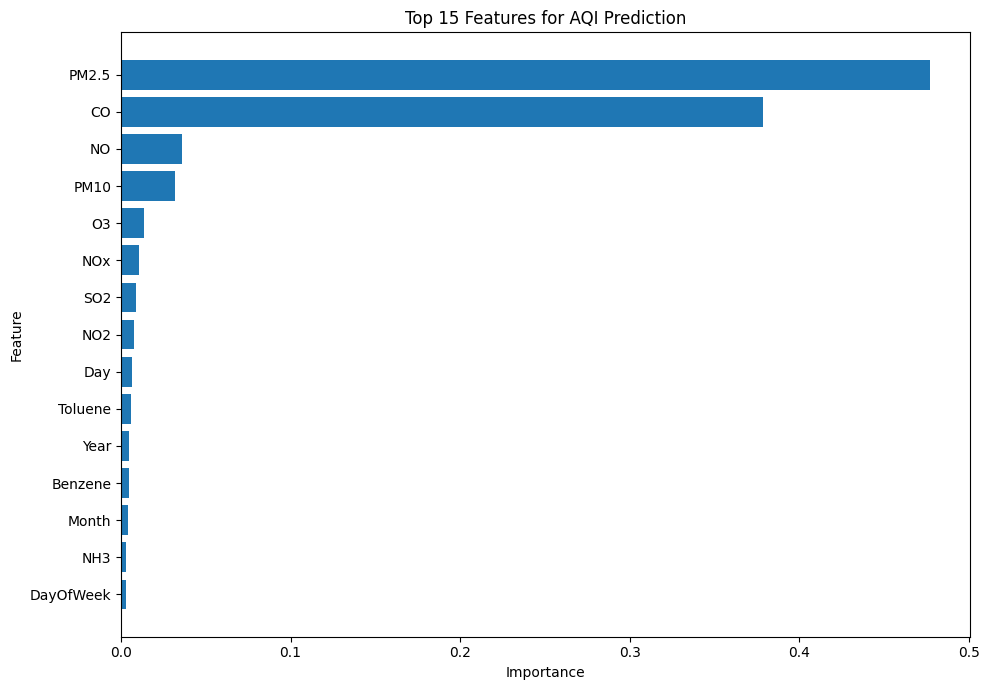

In [132]:
# ============================================================
# Feature Importance Plot — Top 15
# ============================================================

import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features for AQI Prediction")

plt.tight_layout()

plt.savefig(
    "../graphs/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [133]:
feature_importance.to_csv(
    "../data/processed/W3_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


In [134]:
# ============================================================
# W3 — RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import GridSearchCV

print("=" * 60)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 60)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_tuning = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_tuning.fit(X_train, y_train)

print("\nBest parameters:")
print(rf_tuning.best_params_)

print("\nBest CV MAE:")
print(round(-rf_tuning.best_score_, 4))

RANDOM FOREST HYPERPARAMETER TUNING
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Best CV MAE:
28.6866


In [135]:
# ============================================================
# W3 — TIME-SERIES RANDOM FOREST TUNING
# ============================================================

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

print("=" * 60)
print("TIME-SERIES RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 60)

# Time-aware cross-validation
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_tuning_ts = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

rf_tuning_ts.fit(X_train, y_train)

print("\nBest time-series parameters:")
print(rf_tuning_ts.best_params_)

print("\nBest time-series CV MAE:")
print(round(-rf_tuning_ts.best_score_, 4))

TIME-SERIES RANDOM FOREST HYPERPARAMETER TUNING
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best time-series parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Best time-series CV MAE:
27.9152


In [136]:
# ============================================================
# W3 — TUNED RANDOM FOREST TEST EVALUATION
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Get the best time-series tuned model
tuned_rf = rf_tuning_ts.best_estimator_

# Predict on untouched test data
y_pred_tuned_rf = tuned_rf.predict(X_test)

# Evaluation metrics
tuned_rf_mae = mean_absolute_error(y_test, y_pred_tuned_rf)
tuned_rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned_rf))
tuned_rf_r2 = r2_score(y_test, y_pred_tuned_rf)

print("=" * 60)
print("TUNED RANDOM FOREST — TEST SET EVALUATION")
print("=" * 60)

print("MAE  :", round(tuned_rf_mae, 2))
print("RMSE :", round(tuned_rf_rmse, 2))
print("R²   :", round(tuned_rf_r2, 4))

TUNED RANDOM FOREST — TEST SET EVALUATION
MAE  : 16.57
RMSE : 26.85
R²   : 0.911


In [137]:
# ============================================================
# W3 — FINAL MODEL RESIDUAL ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Residuals
residuals = y_test - y_pred_tuned_rf

print("=" * 60)
print("FINAL MODEL RESIDUAL ANALYSIS")
print("=" * 60)

print("Mean residual :", round(np.mean(residuals), 2))
print("Median residual :", round(np.median(residuals), 2))
print("Minimum residual :", round(np.min(residuals), 2))
print("Maximum residual :", round(np.max(residuals), 2))
print("Residual standard deviation :", round(np.std(residuals), 2))

FINAL MODEL RESIDUAL ANALYSIS
Mean residual : -3.94
Median residual : -5.38
Minimum residual : -271.8
Maximum residual : 508.56
Residual standard deviation : 26.56


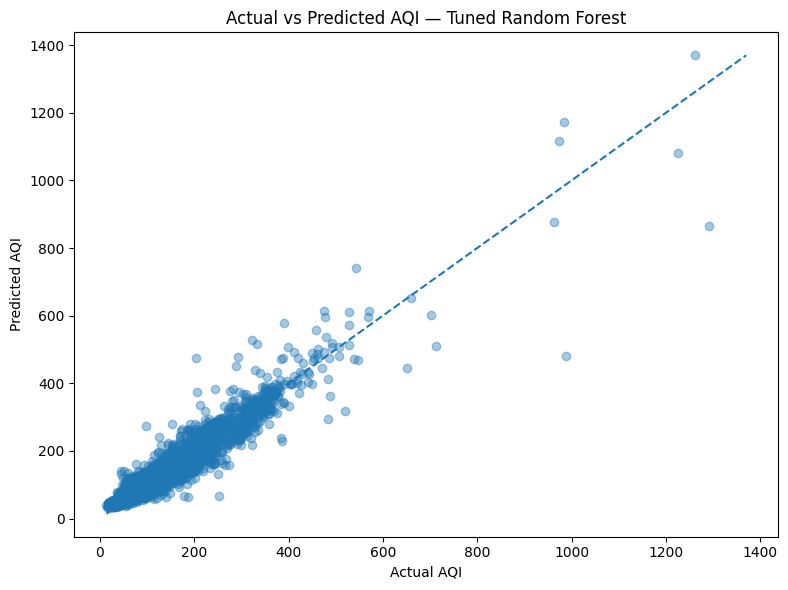

In [138]:
# ============================================================
# ACTUAL VS PREDICTED AQI
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_tuned_rf,
    alpha=0.4
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_tuned_rf.min())
max_val = max(y_test.max(), y_pred_tuned_rf.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI — Tuned Random Forest")

plt.tight_layout()

plt.savefig(
    "../graphs/w3_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

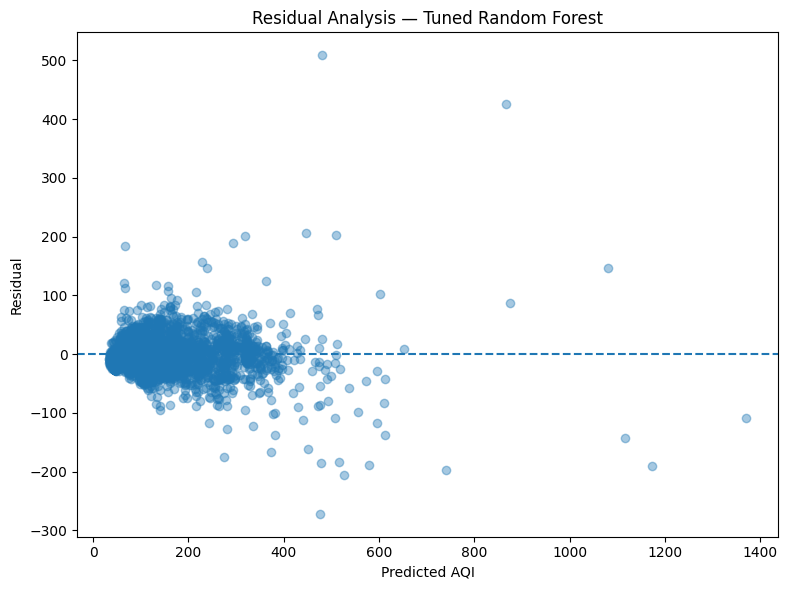

In [139]:
# ============================================================
# RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_tuned_rf,
    residuals,
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted AQI")
plt.ylabel("Residual")
plt.title("Residual Analysis — Tuned Random Forest")

plt.tight_layout()

plt.savefig(
    "../graphs/w3_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [140]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

import joblib

final_model_path = "../data/processed/AeroPure_final_random_forest.pkl"

joblib.dump(
    tuned_rf,
    final_model_path
)

print("Final model saved successfully.")
print("File:", final_model_path)

Final model saved successfully.
File: ../data/processed/AeroPure_final_random_forest.pkl
